# Project Visual Summary

A visual-first summary of model evidence for approved applications. Metrics use thousands of US dollars unless stated otherwise.

In [1]:
import os
from stage9_visual_summary_builder import run
result = run(os.environ.get('VISUAL_SUMMARY_MODE', 'cache'))
print(f"Validated {result['figures']} figures and {result['tables']} tables.")

Validated 20 figures and 8 tables.


## 1. Roadmap and Data

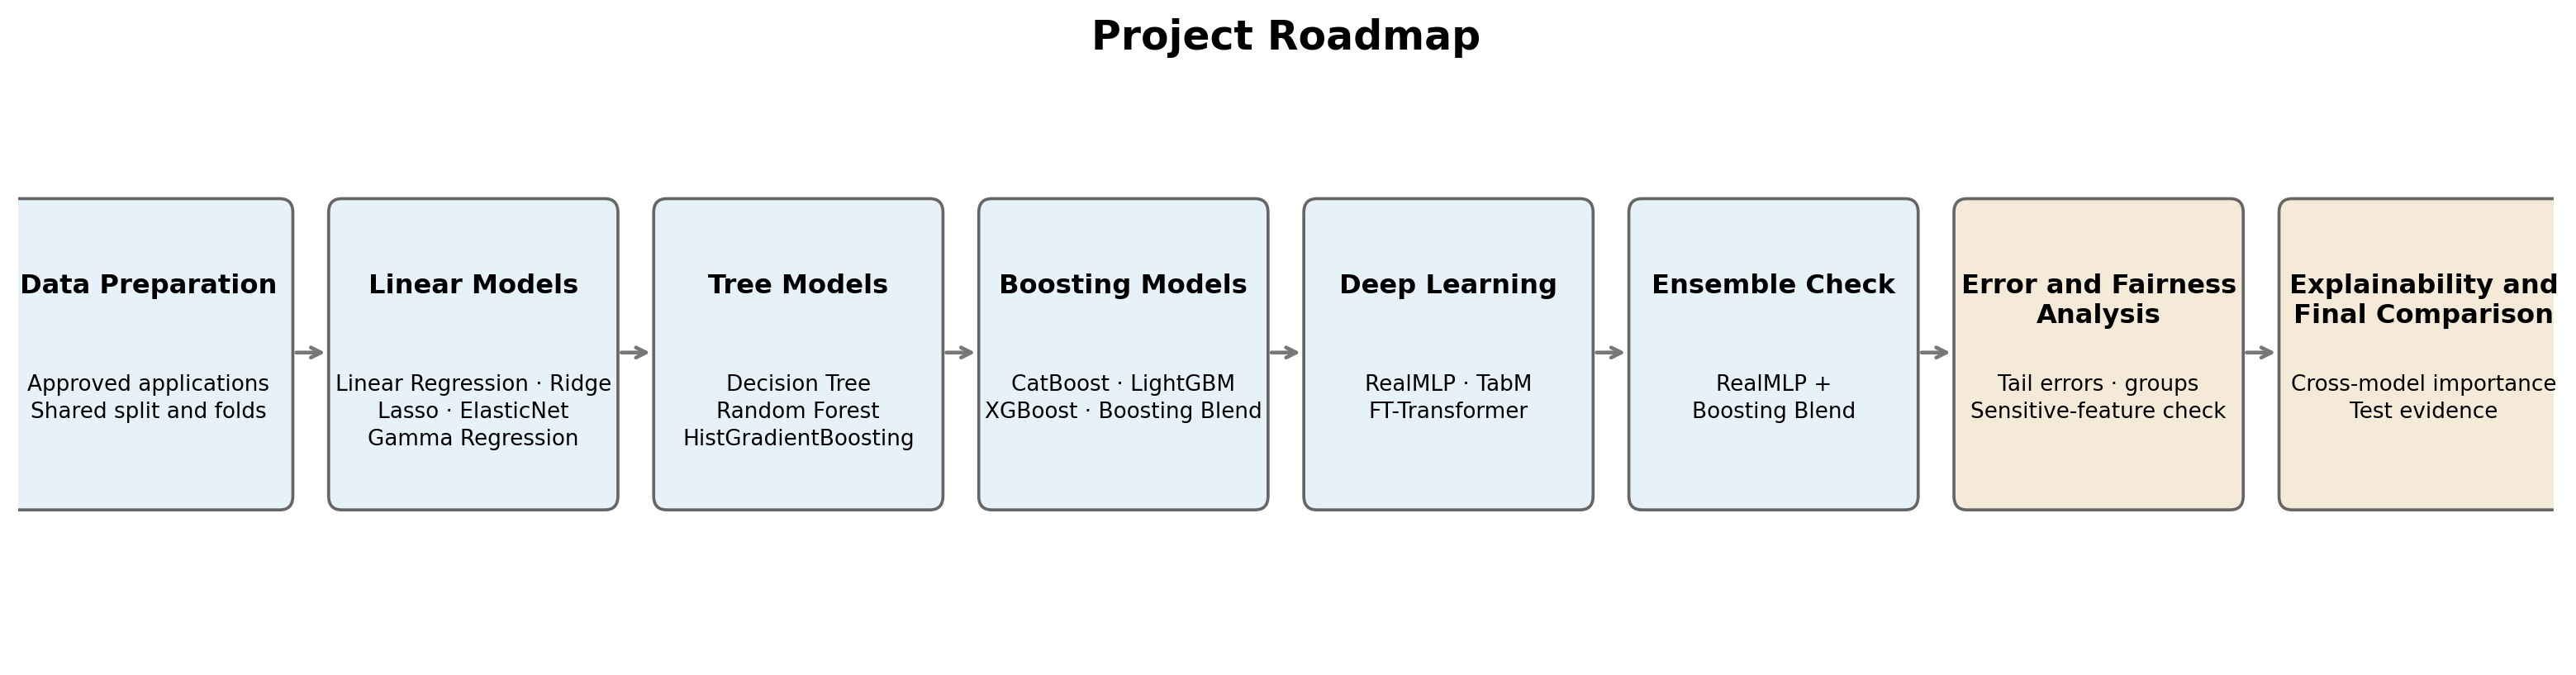

In [2]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_01_project_roadmap.png'))

**Main finding:** The workflow progressed from data preparation through model comparison, diagnostics, and explanation.

**Why it matters:** The roadmap connects each model family to its analytical role without internal process labels.

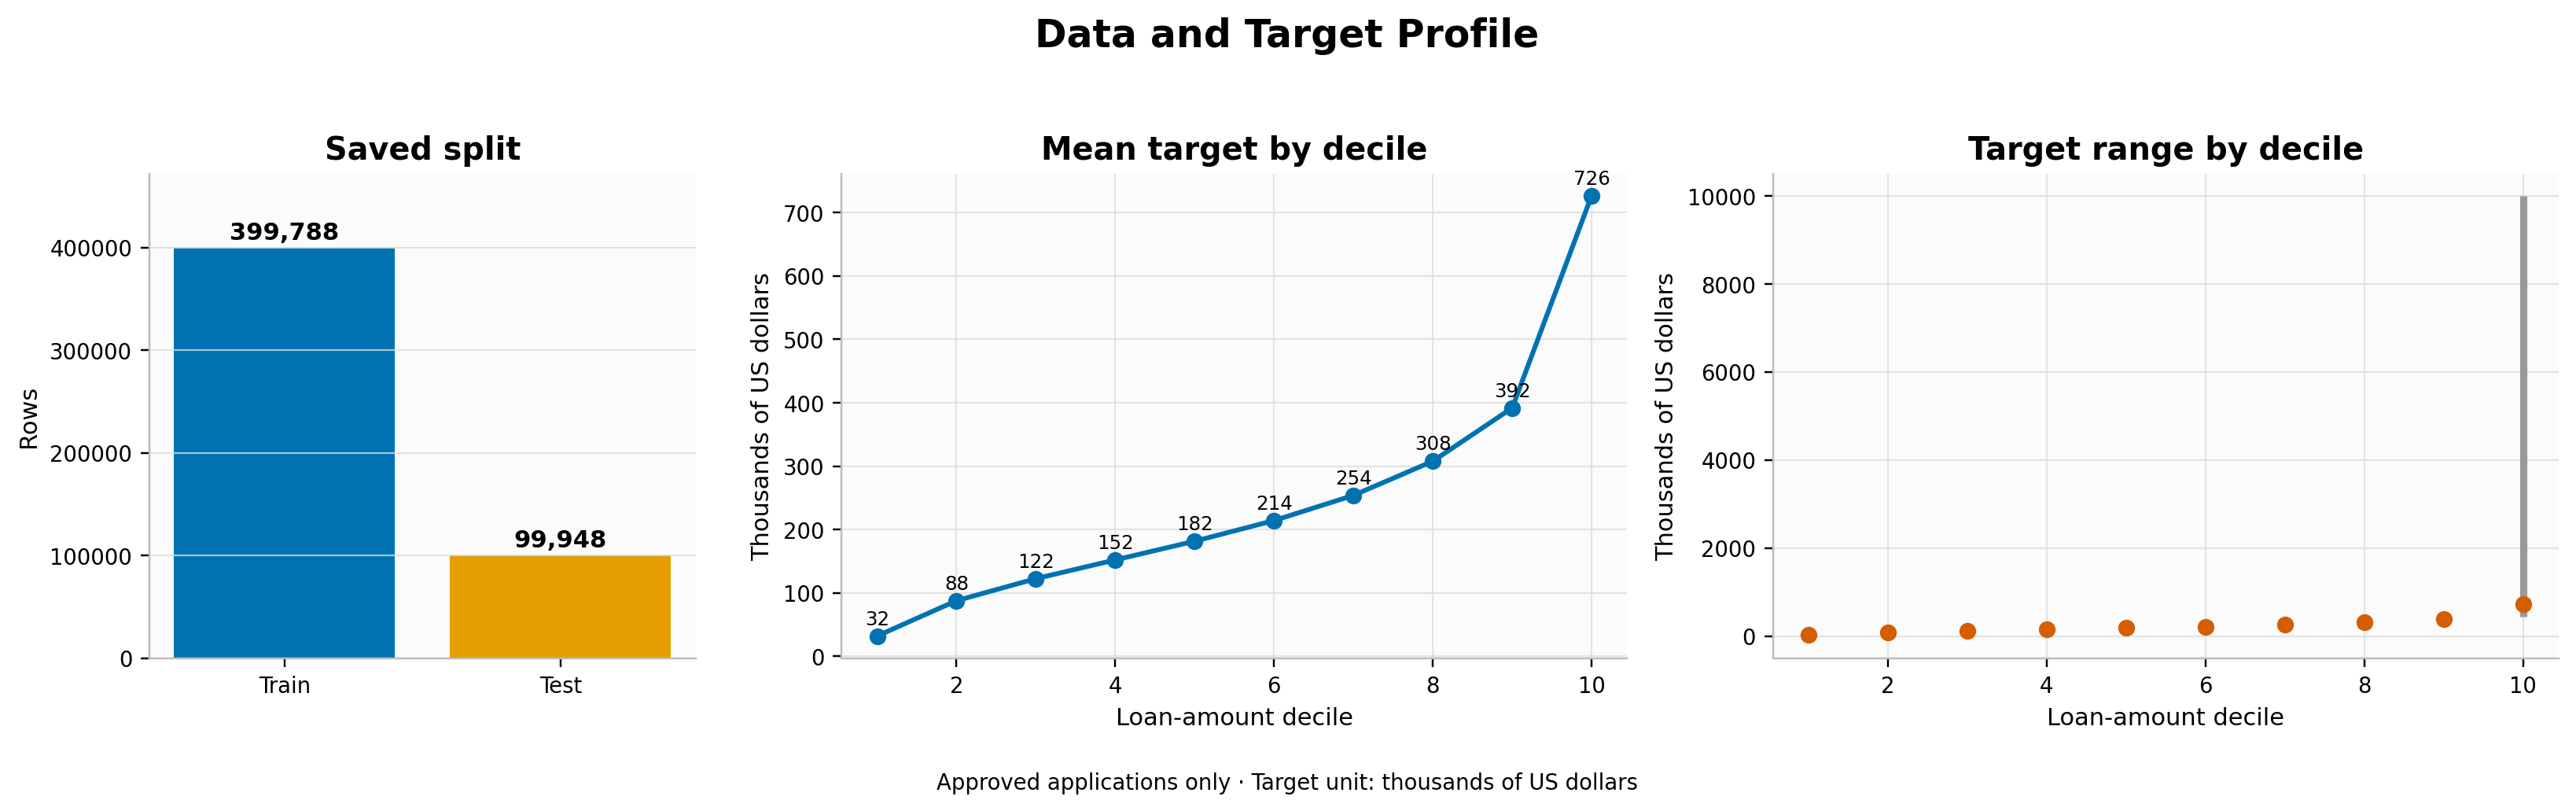

In [3]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_02_data_target_profile.png'))

**Main finding:** The saved split contains 399,788 Train rows and 99,948 Test rows, with target amounts rising sharply in the highest decile.

**Why it matters:** The upper target range anticipates the large-loan error challenge seen later.

**Table 1 — Dataset Summary**

In [4]:
import pandas as pd
from IPython.display import display
_table = pd.read_csv('artifacts/results/stage9_visual_summary/stage9_visual_summary_dataset_table.csv')
display(_table.style.hide(axis='index').format(precision=3))

Total rows,Train rows,Test rows,Target,Unit,Scope
499736,399788,99948,Loan amount,Thousands of US dollars,Approved applications only


## 2. All Models at a Glance

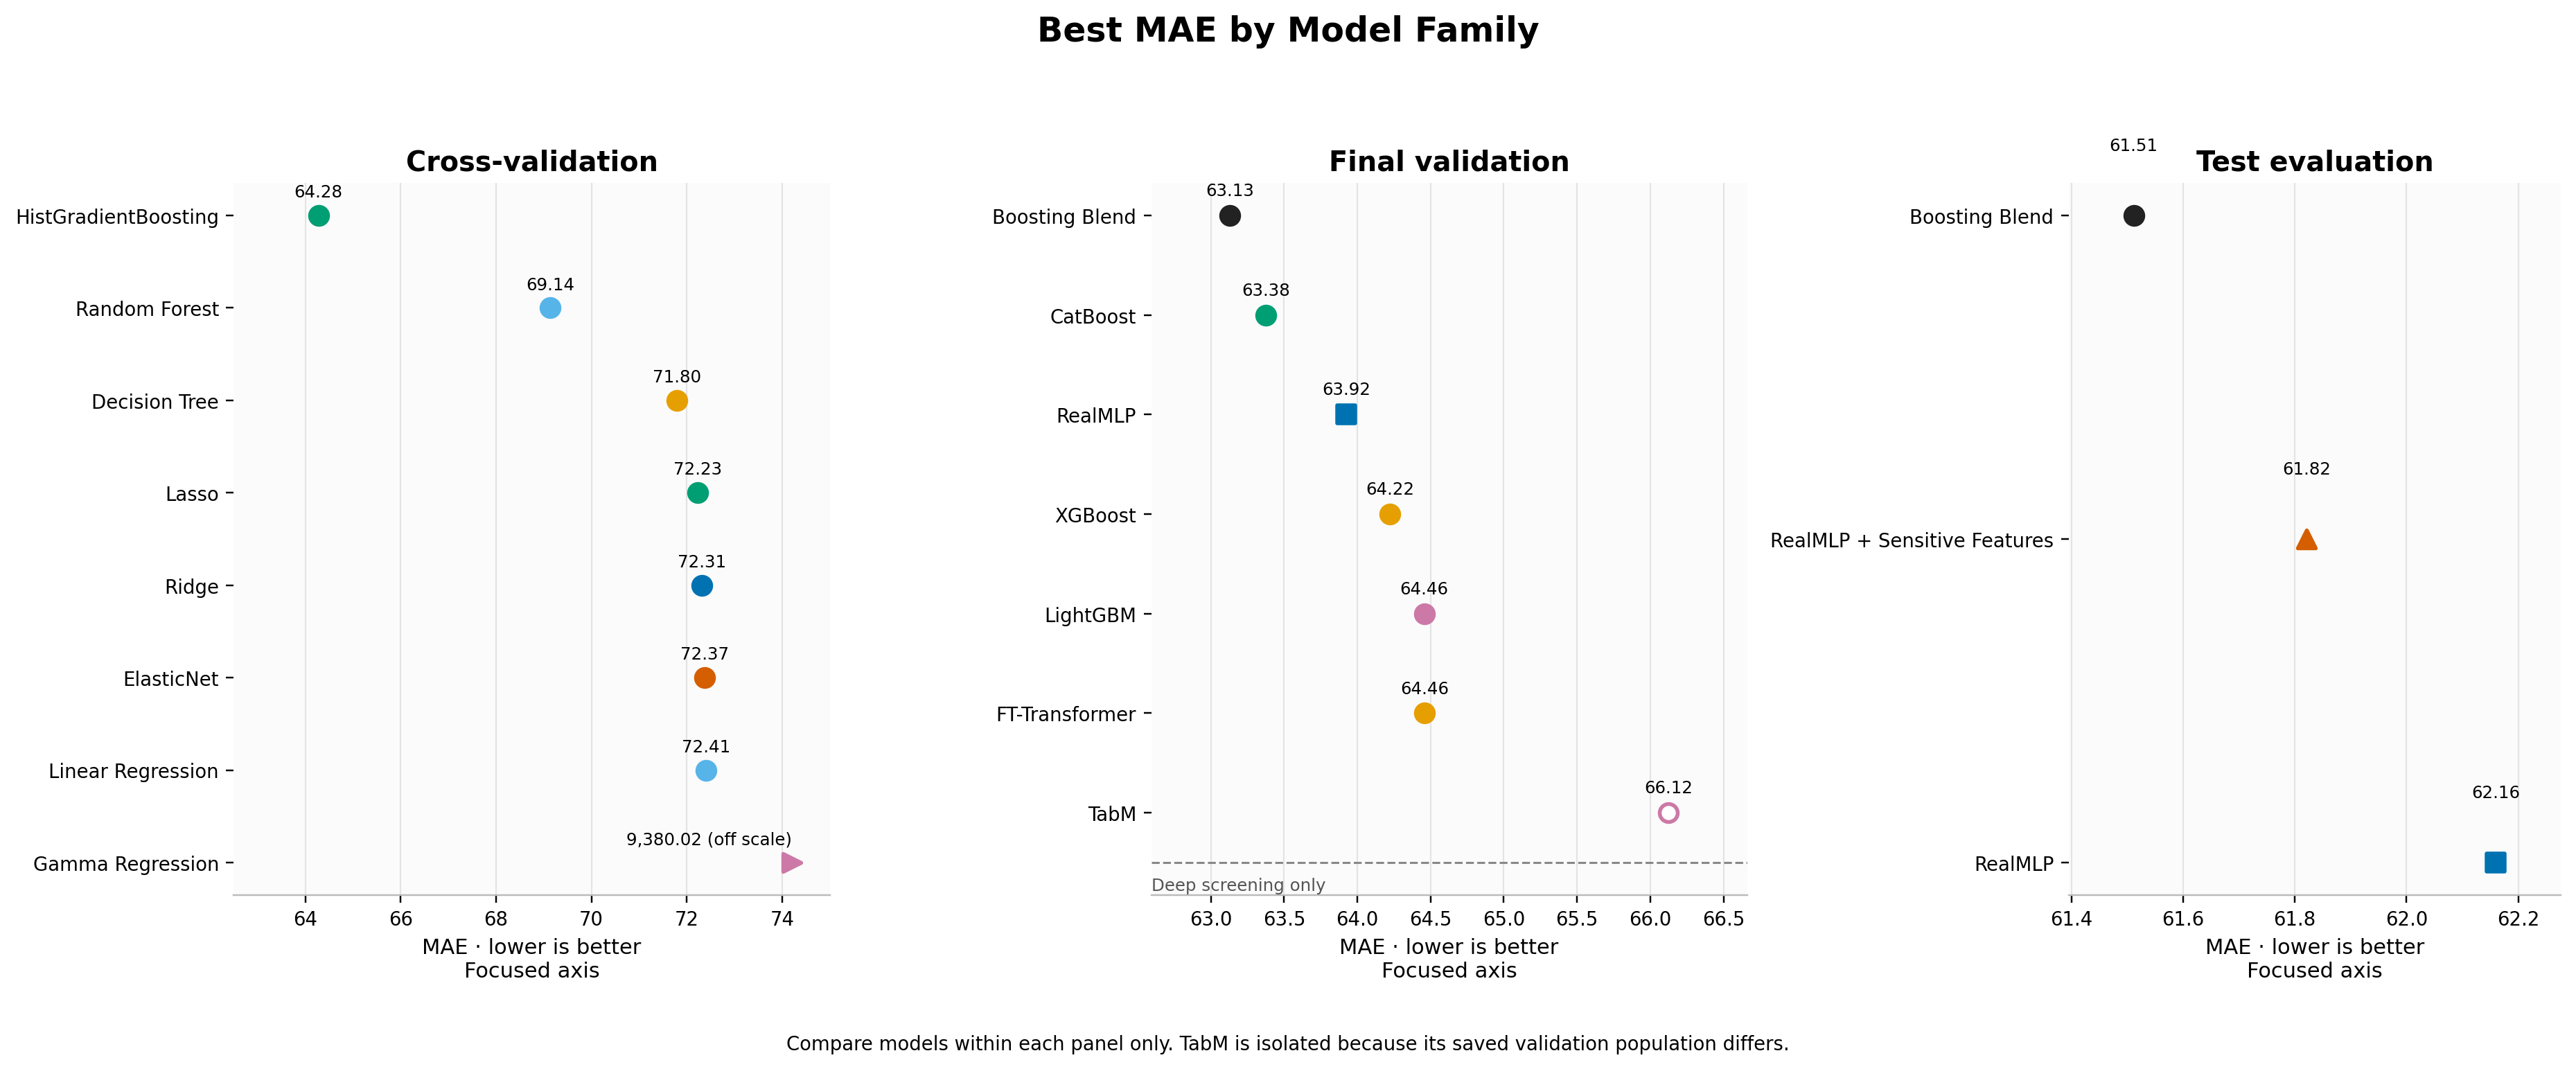

In [5]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_03_best_mae_by_family.png'))

**Main finding:** MAE improved substantially from linear and tree baselines to boosting and deep models within their own evaluation scopes.

**Why it matters:** Scope separation prevents a false leaderboard across different populations.

**Table 2 — Model Family Catalog**

In [6]:
import pandas as pd
from IPython.display import display
_table = pd.read_csv('artifacts/results/stage9_visual_summary/stage9_visual_summary_model_catalog.csv')
display(_table.style.hide(axis='index').format(precision=3))

Model,Family,Evaluation scope,Sensitive Features,Target mode,MAE,RMSE,R²,Selection role
Linear Regression,Linear,Cross-validation,No,log1p,72.410,294.860,0.139,Benchmark
Ridge,Linear,Cross-validation,No,log1p,72.311,257.837,0.341,Benchmark
Lasso,Linear,Cross-validation,No,log1p,72.230,245.237,0.404,Continued
ElasticNet,Linear,Cross-validation,No,log1p,72.370,246.247,0.399,Benchmark
Gamma Regression,Generalized linear,Cross-validation,No,raw,9380.022,5868624.062,-341168064.263,Benchmark
Decision Tree,Tree,Cross-validation,No,log1p,71.800,254.640,0.358,Benchmark
Random Forest,Tree,Cross-validation,No,log1p,69.142,255.854,0.352,Benchmark
HistGradientBoosting,Tree boosting,Cross-validation,No,log1p,64.276,249.122,0.385,Continued
CatBoost,Boosting,Validation,No,log1p,63.376,130.272,nan,Blend component
LightGBM,Boosting,Validation,No,raw,64.457,131.956,nan,Blend component


## 3. Classical Models

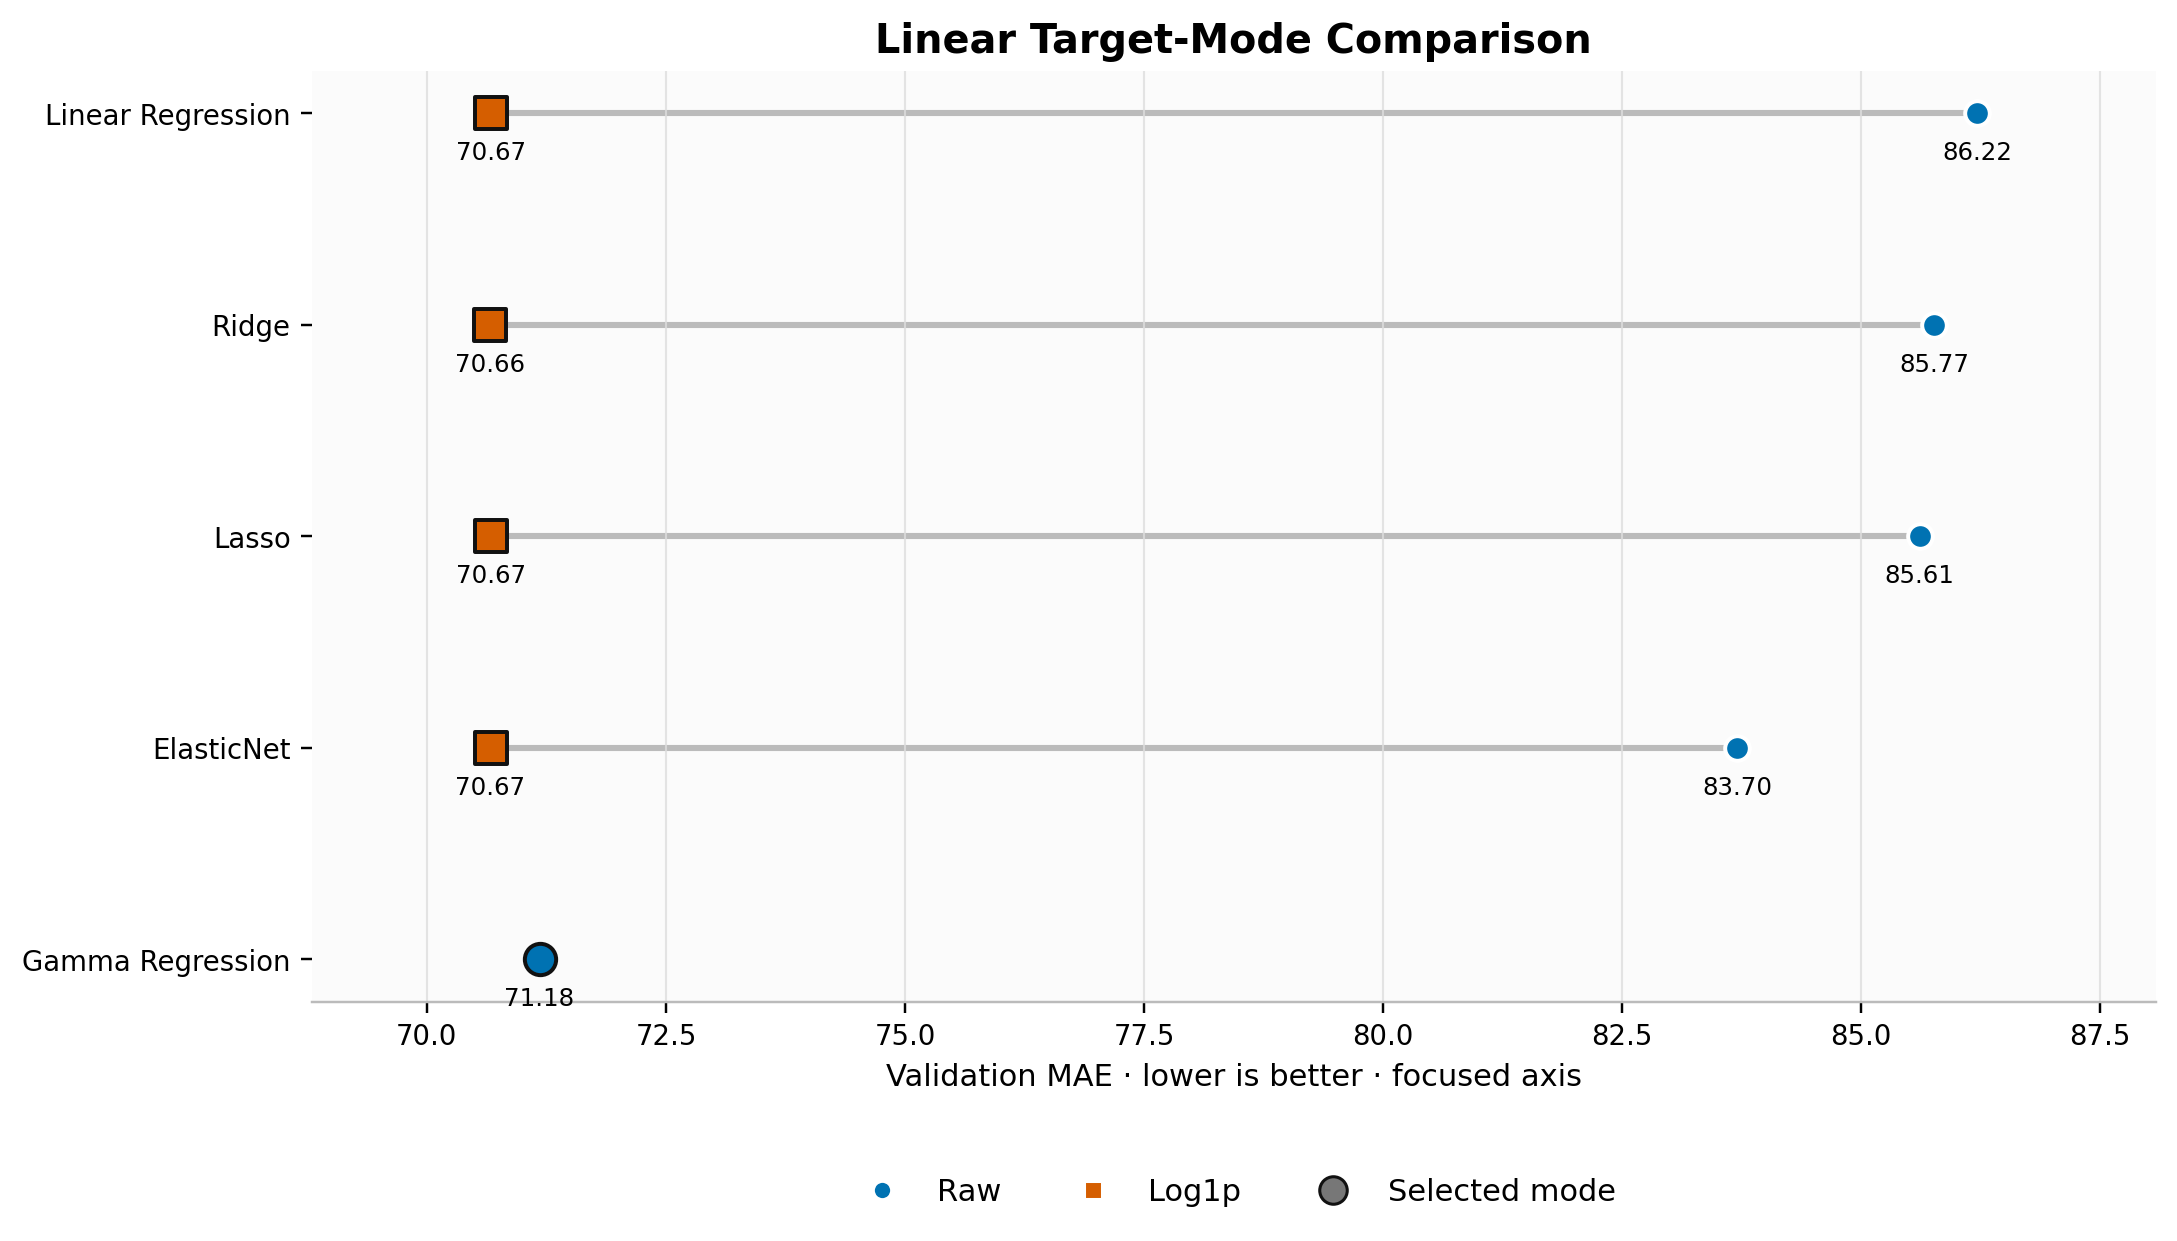

In [7]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_04_linear_model_comparison.png'))

**Main finding:** Log1p targets reduced MAE for all five linear families on the shared validation population.

**Why it matters:** Target transformation mattered more than small differences among the strongest linear variants.

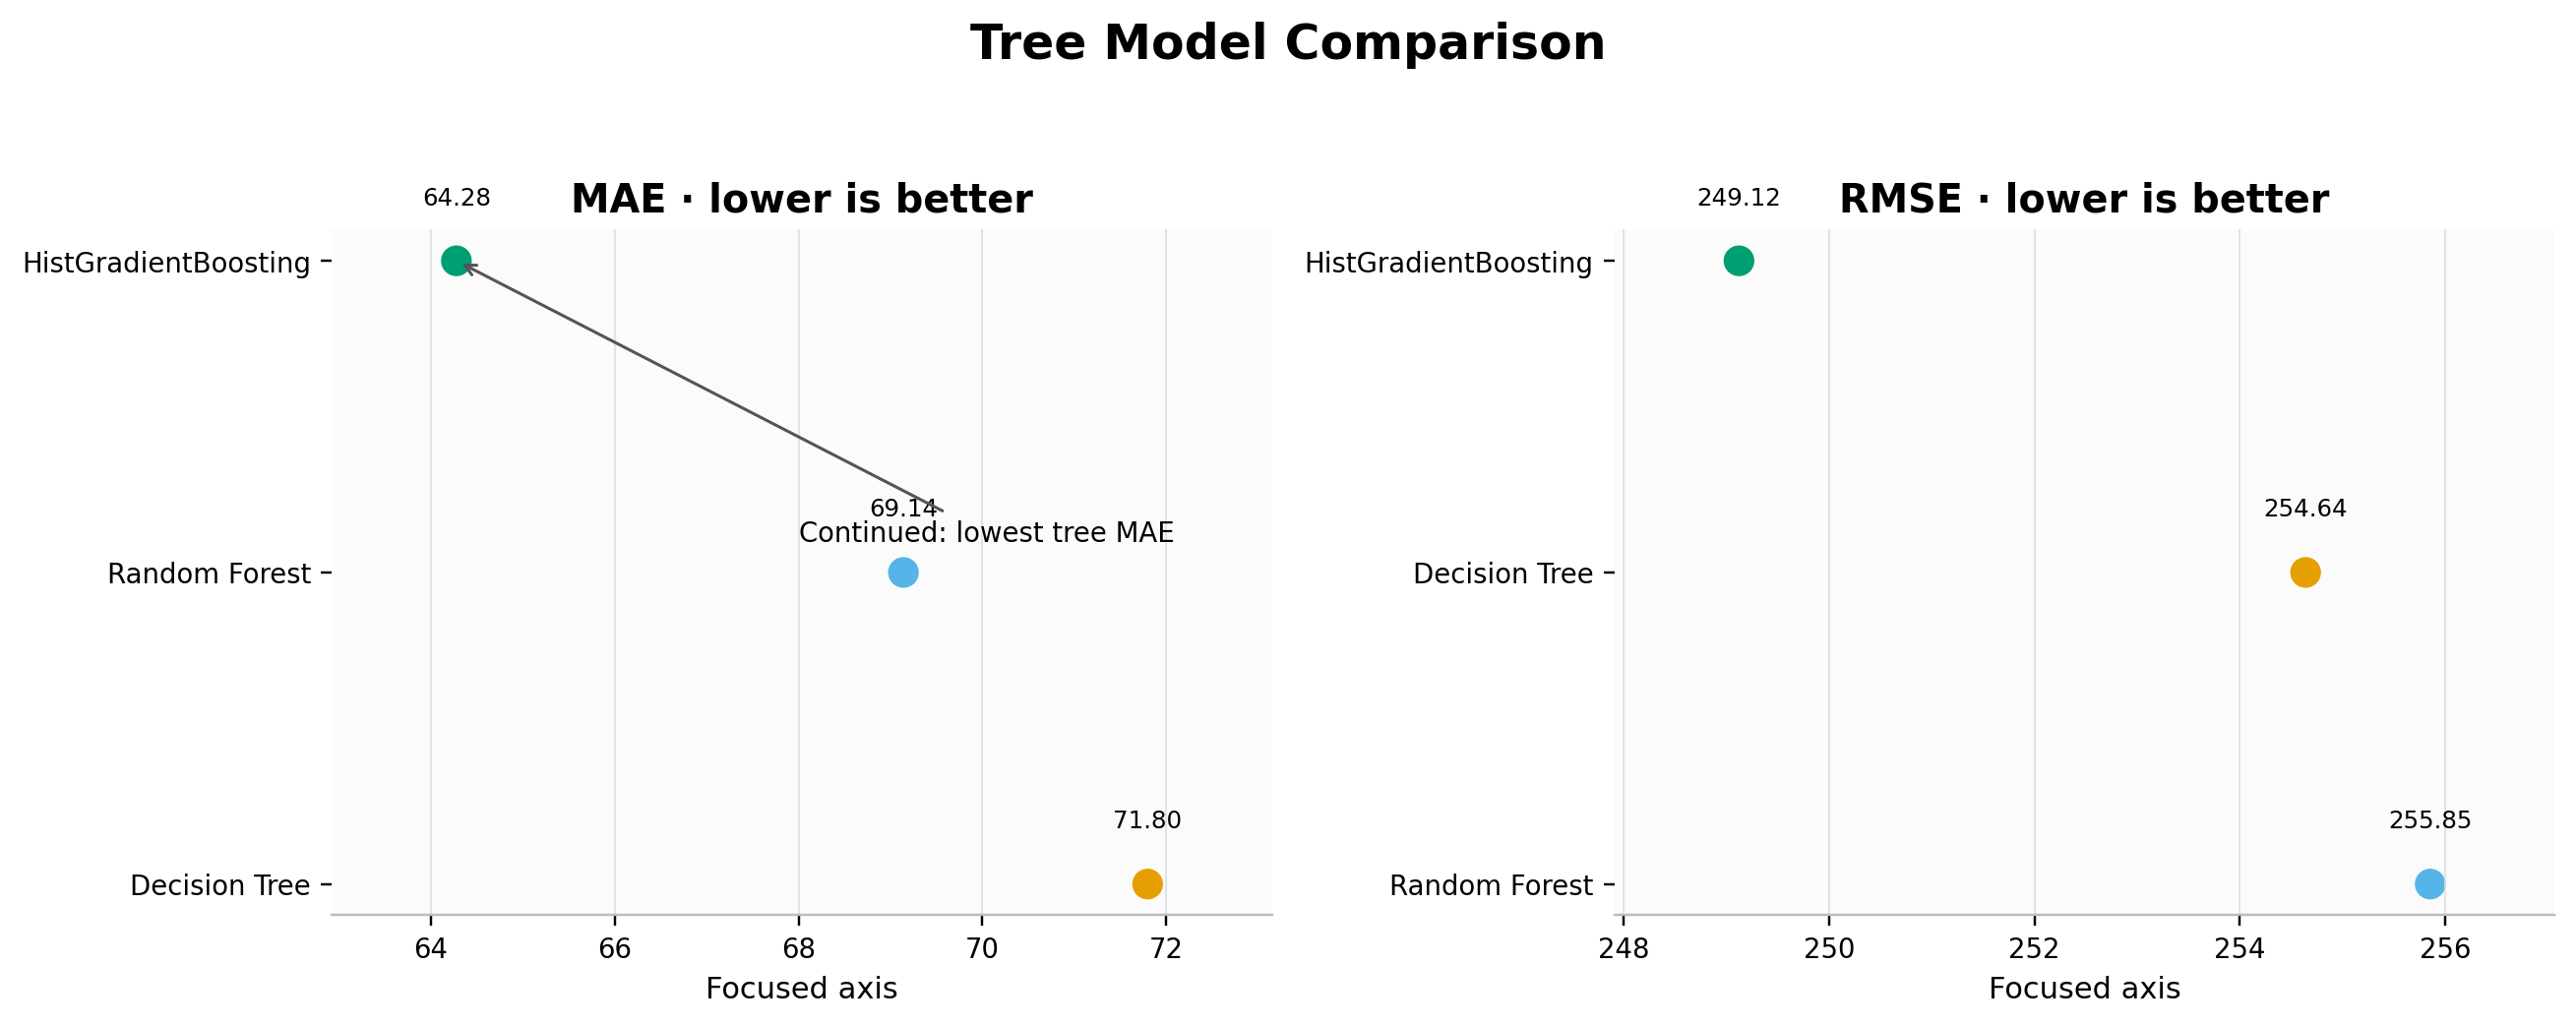

In [8]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_05_tree_model_comparison.png'))

**Main finding:** HistGradientBoosting had the lowest cross-validated tree-family MAE.

**Why it matters:** This quantitative advantage justified continuing to stronger boosting methods.

## 4. Boosting and Feature Engineering

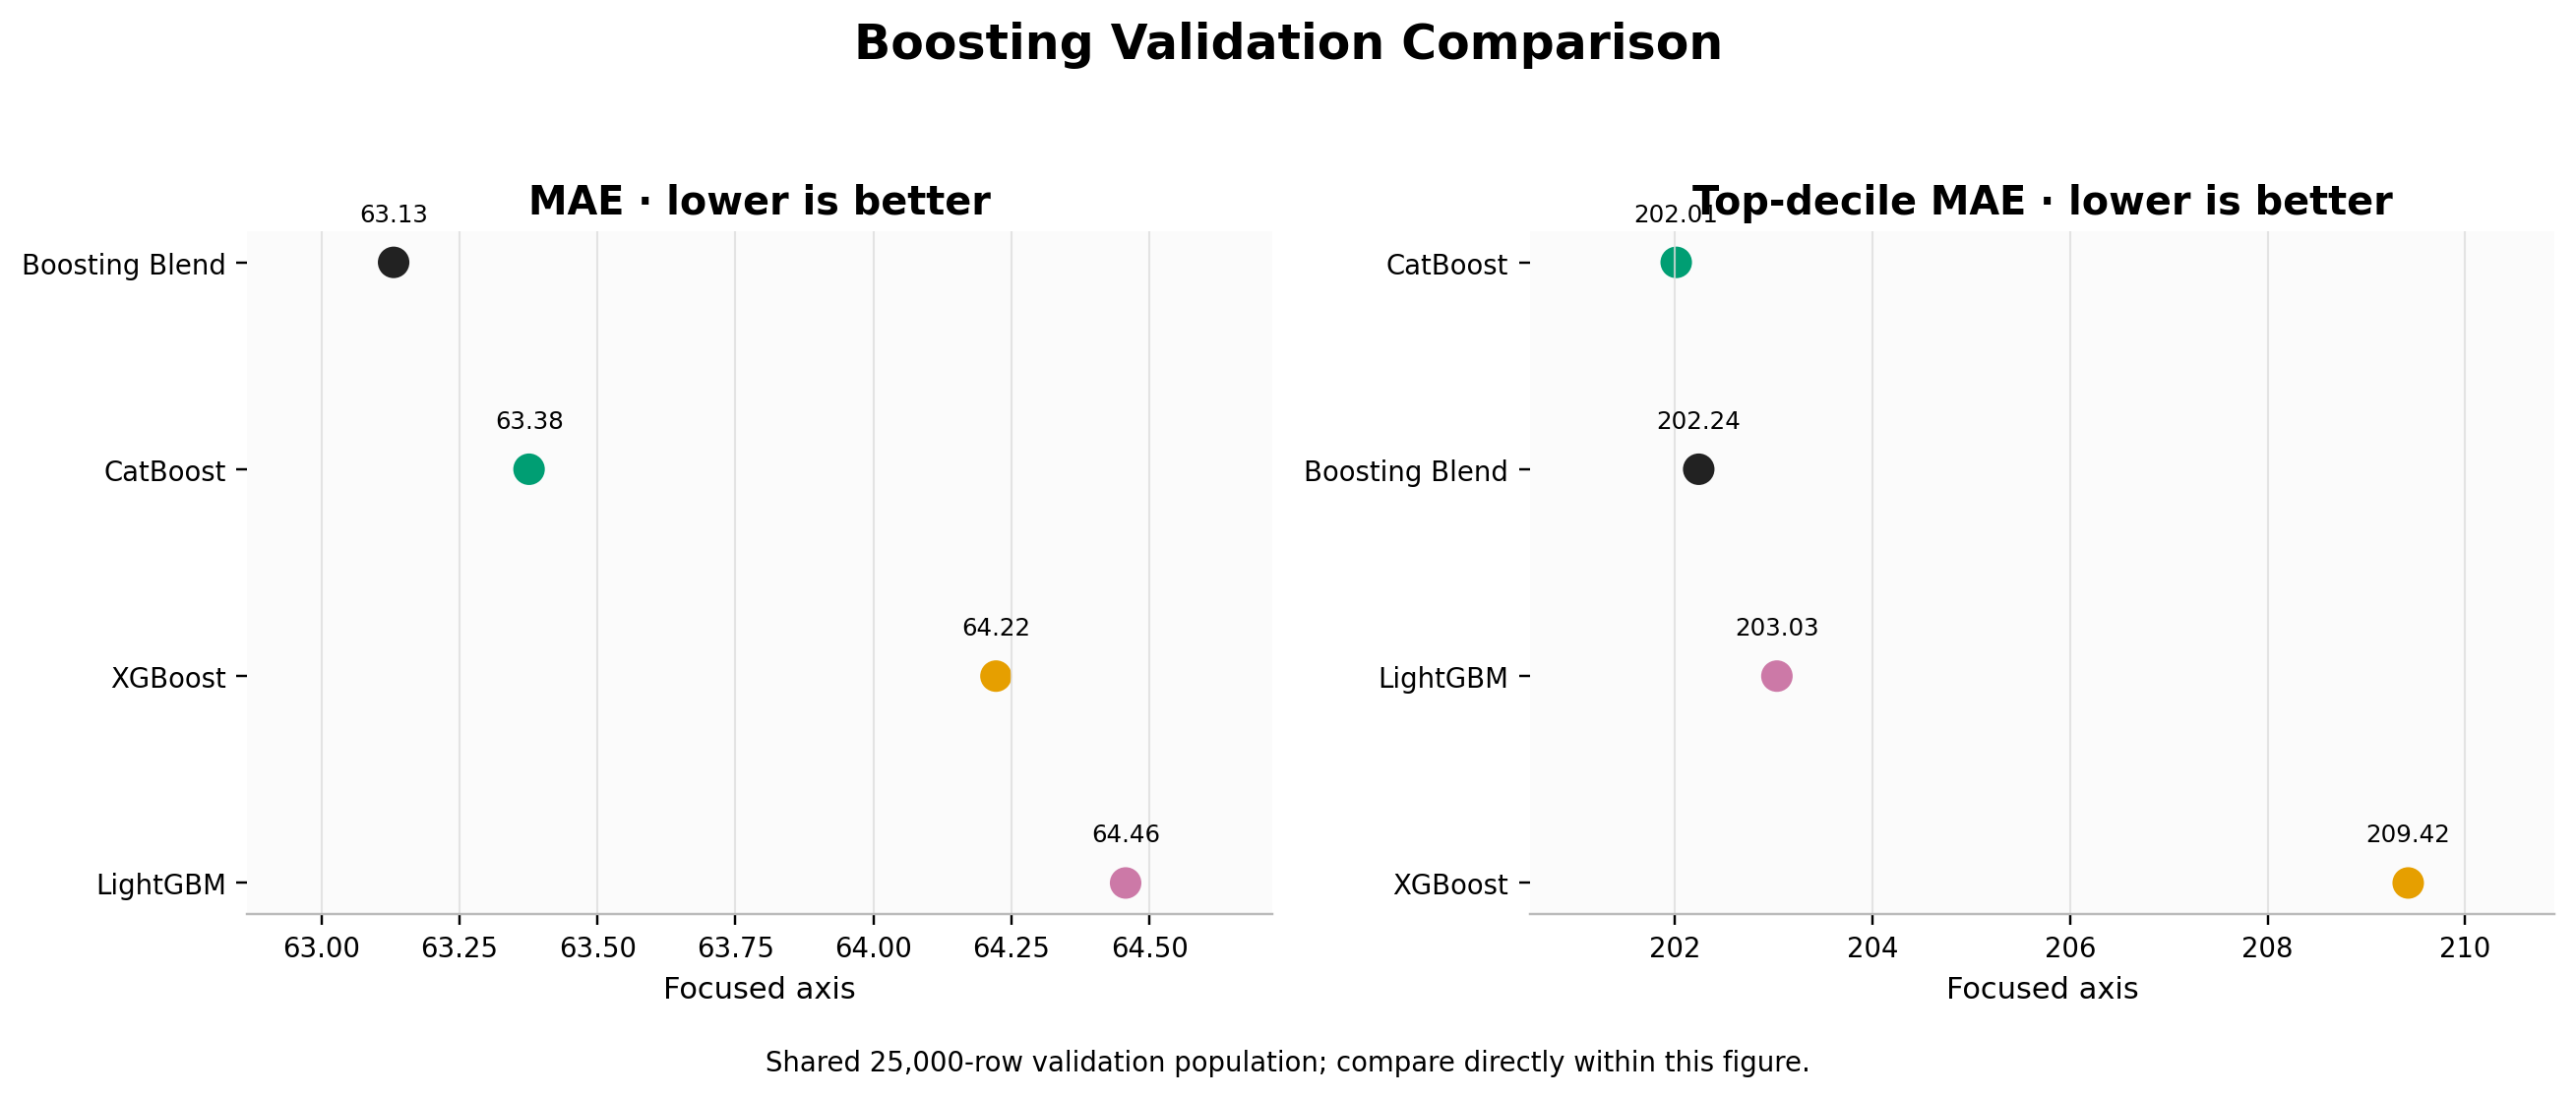

In [9]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_06_boosting_model_comparison.png'))

**Main finding:** The Boosting Blend achieved the lowest validation MAE, while CatBoost had the best single-model result.

**Why it matters:** Complementary component errors improved the blend without using Test evidence.

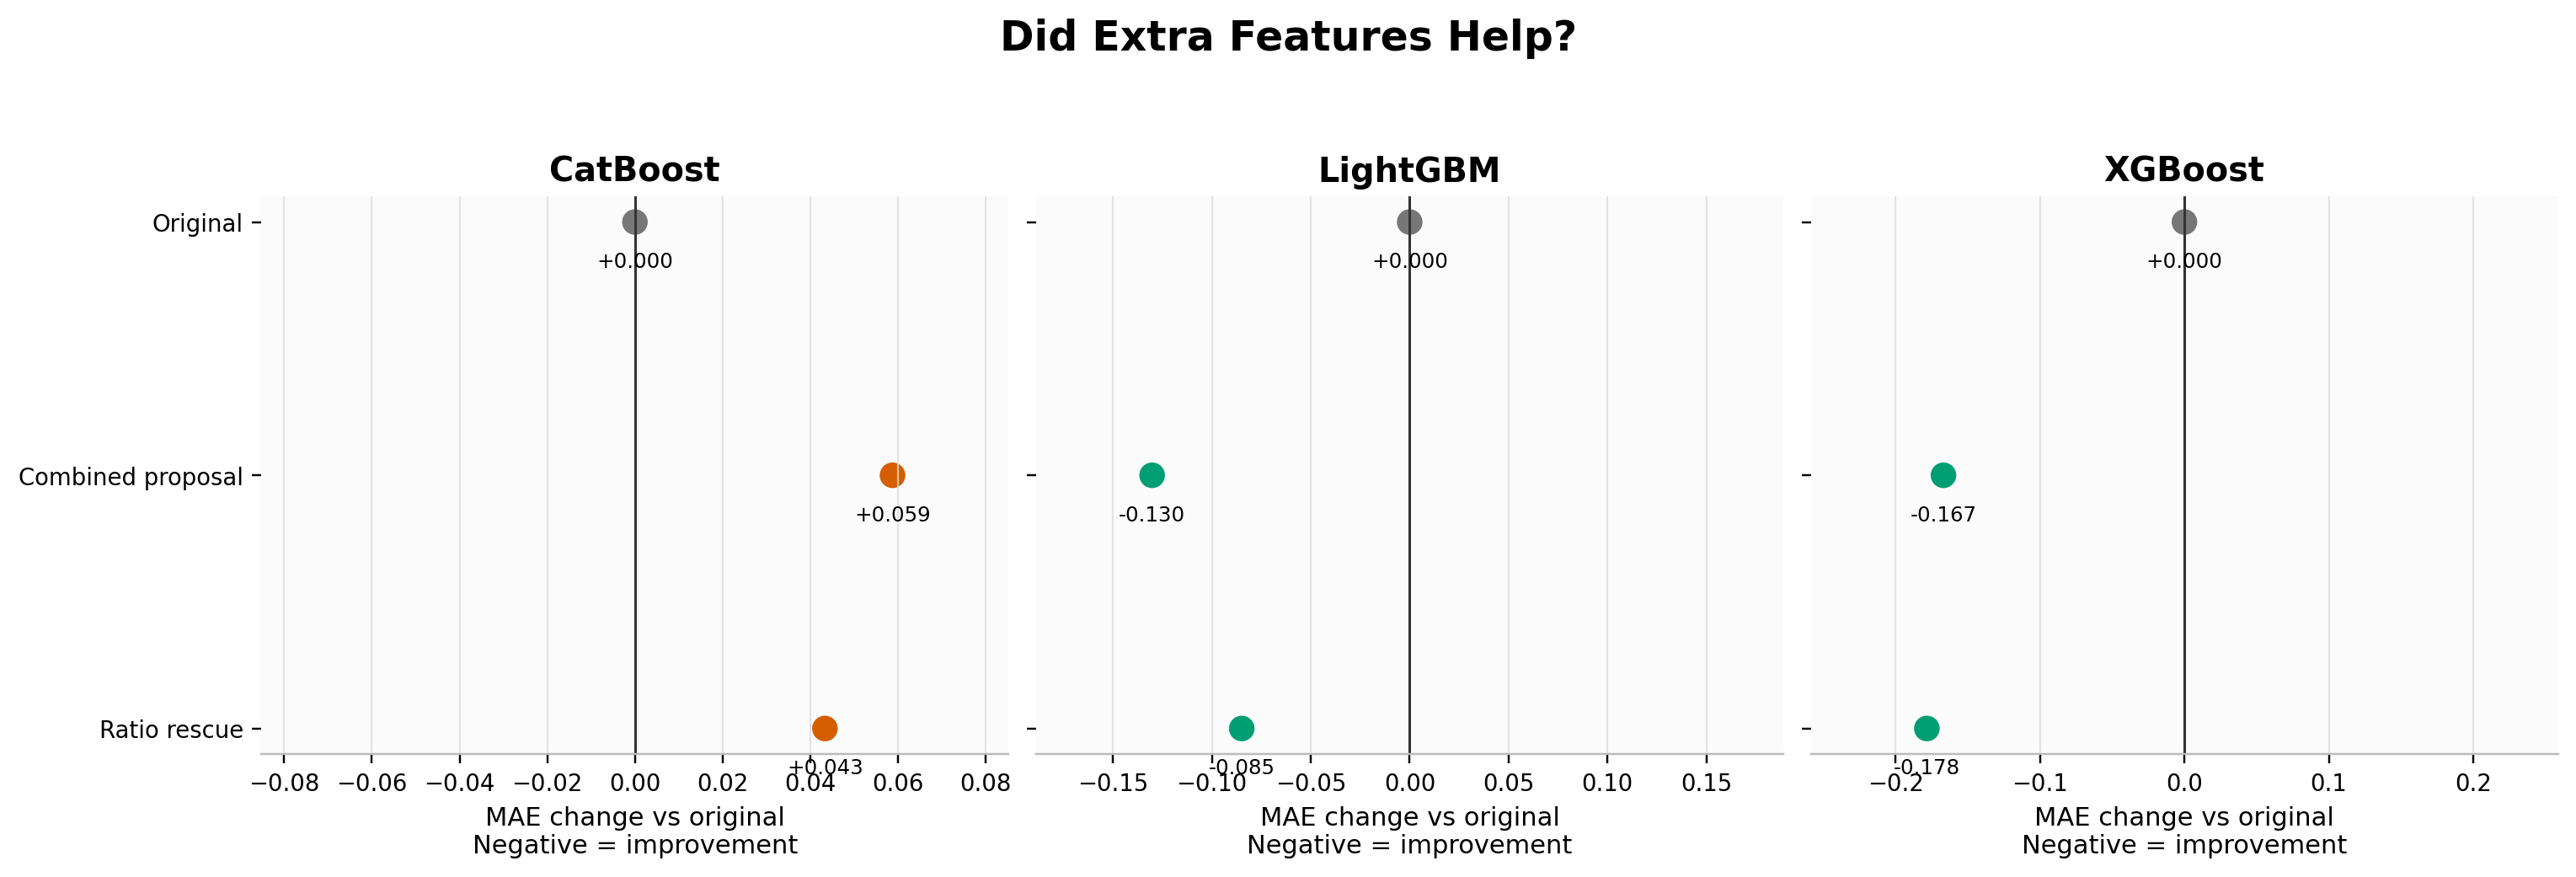

In [10]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_07_feature_engineering_confirmation.png'))

**Main finding:** Proposed Features produced small, family-specific MAE changes rather than a universal gain.

**Why it matters:** Separate panels show why Feature decisions were confirmed independently for each boosting family.

## 5. Deep Learning Models

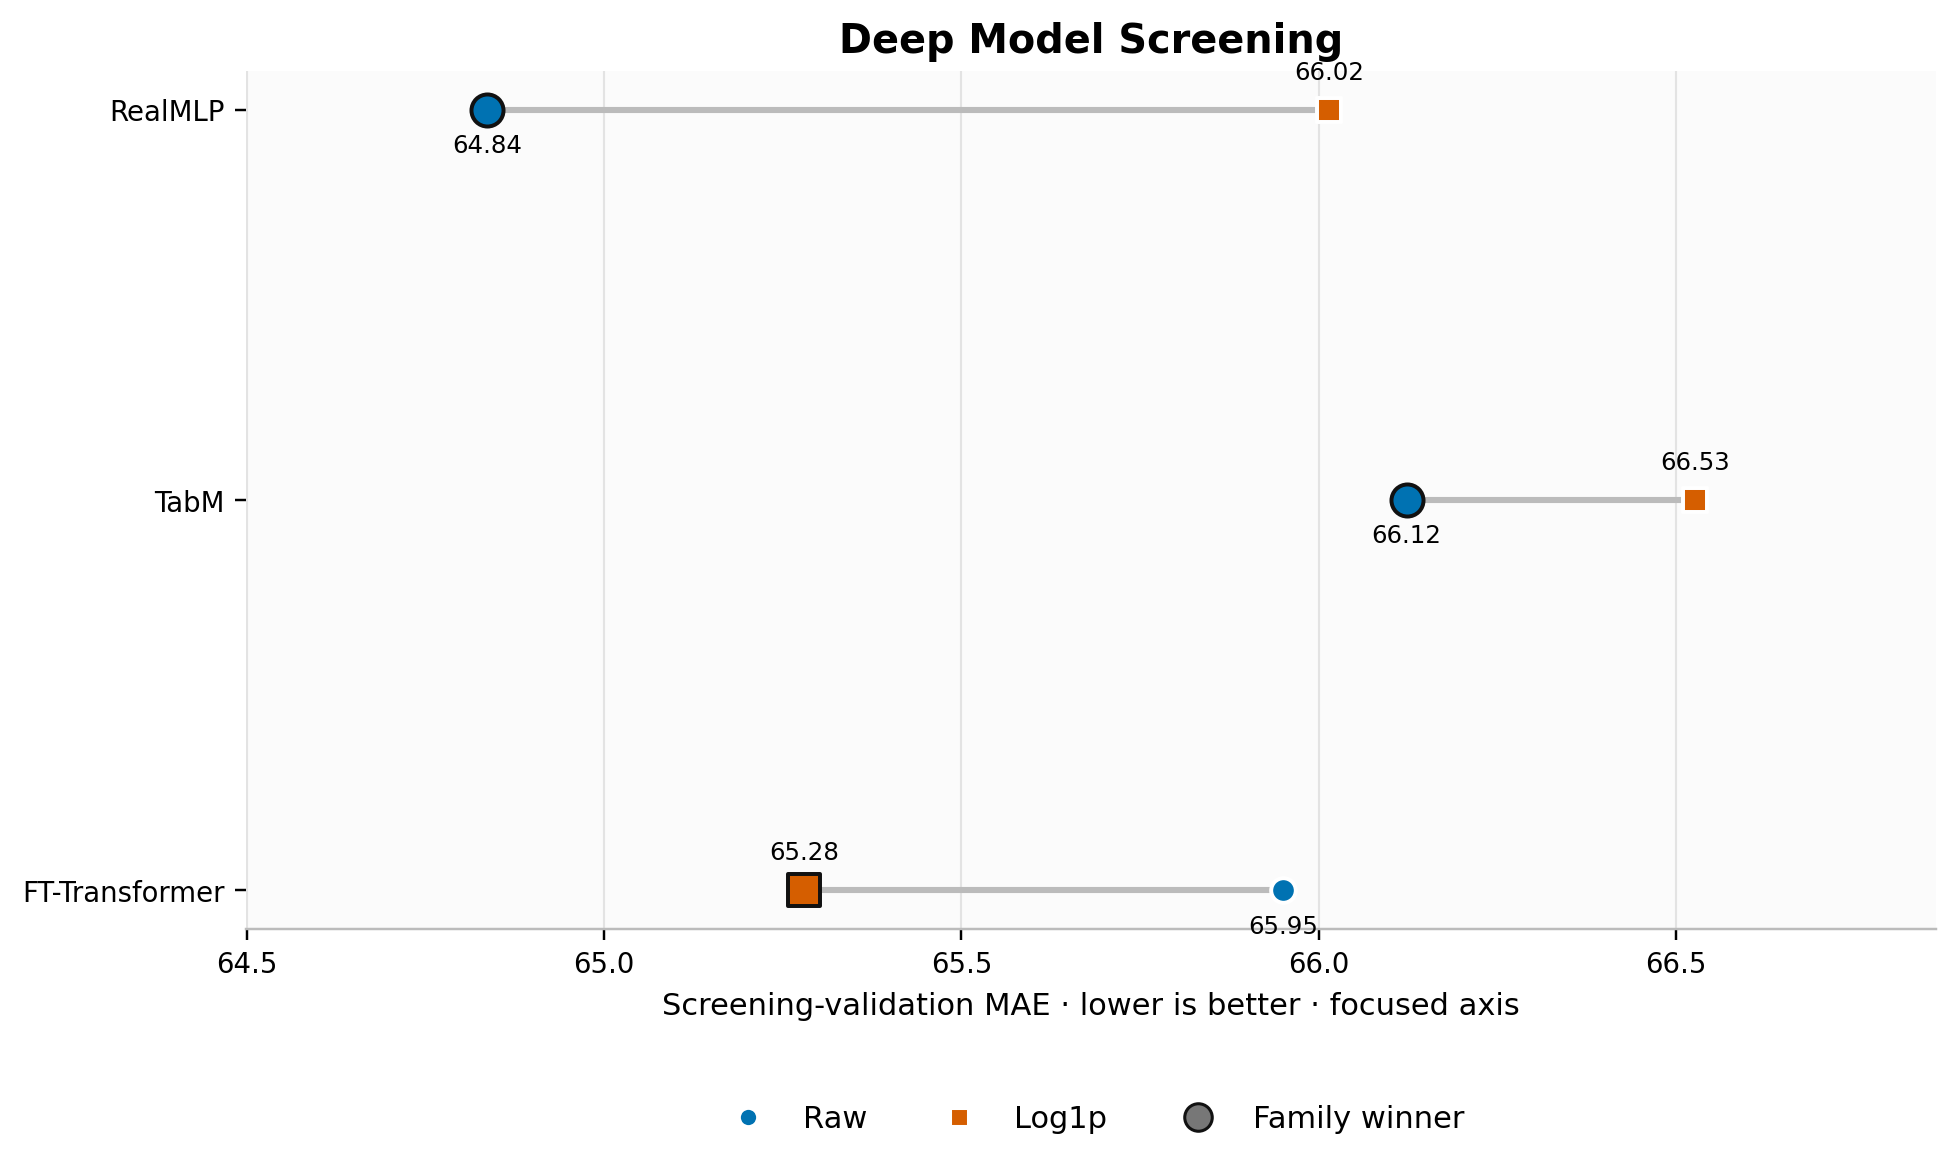

In [11]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_08_deep_model_comparison.png'))

**Main finding:** RealMLP with a raw target led deep screening, while FT-Transformer favored log1p.

**Why it matters:** The family winners defined which deep configurations received later validation.

## 6. Final Test Comparison

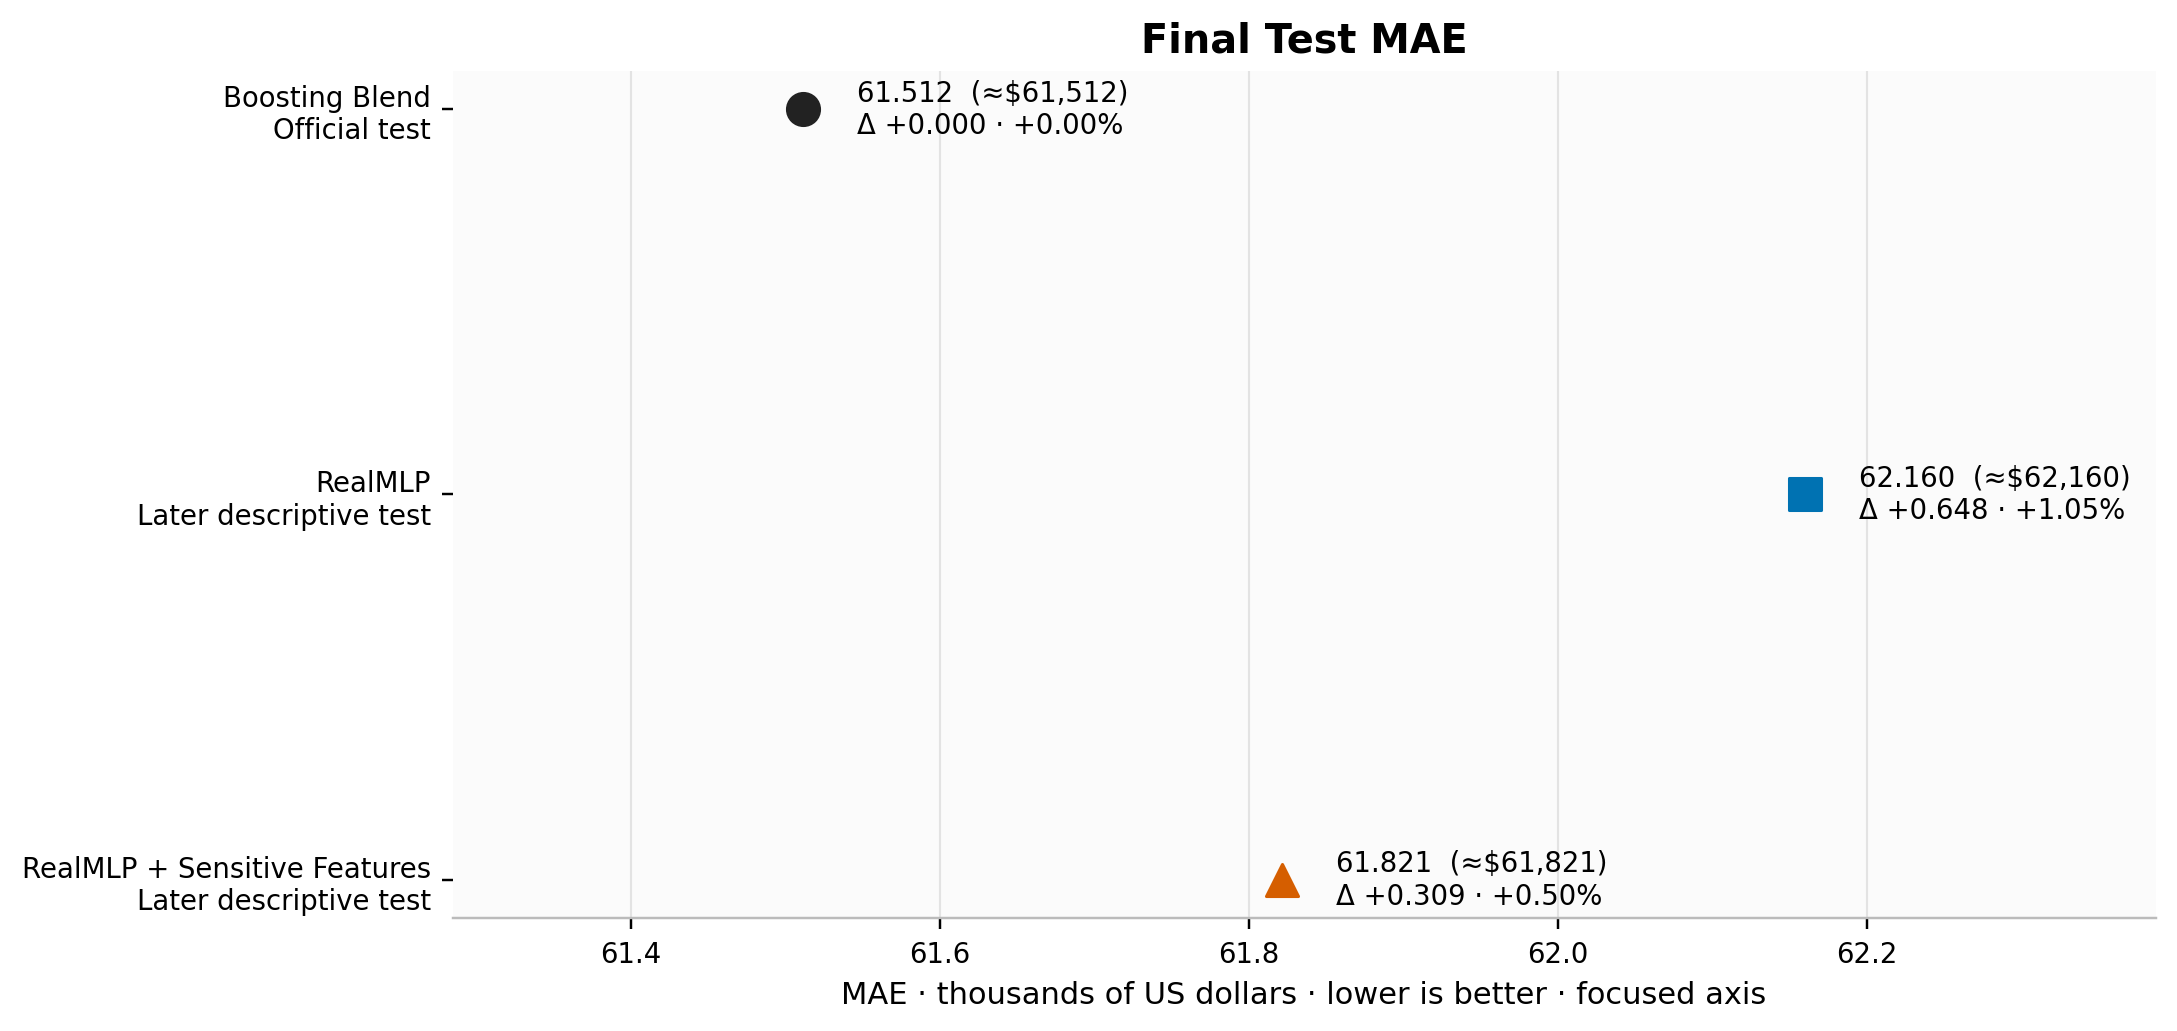

In [12]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_09_final_test_mae.png'))

**Main finding:** Boosting Blend retained the lowest Test MAE; the sensitive-feature RealMLP was closer than RealMLP alone.

**Why it matters:** Only the Boosting Blend result is the official test, while both deep results are later descriptive comparisons.

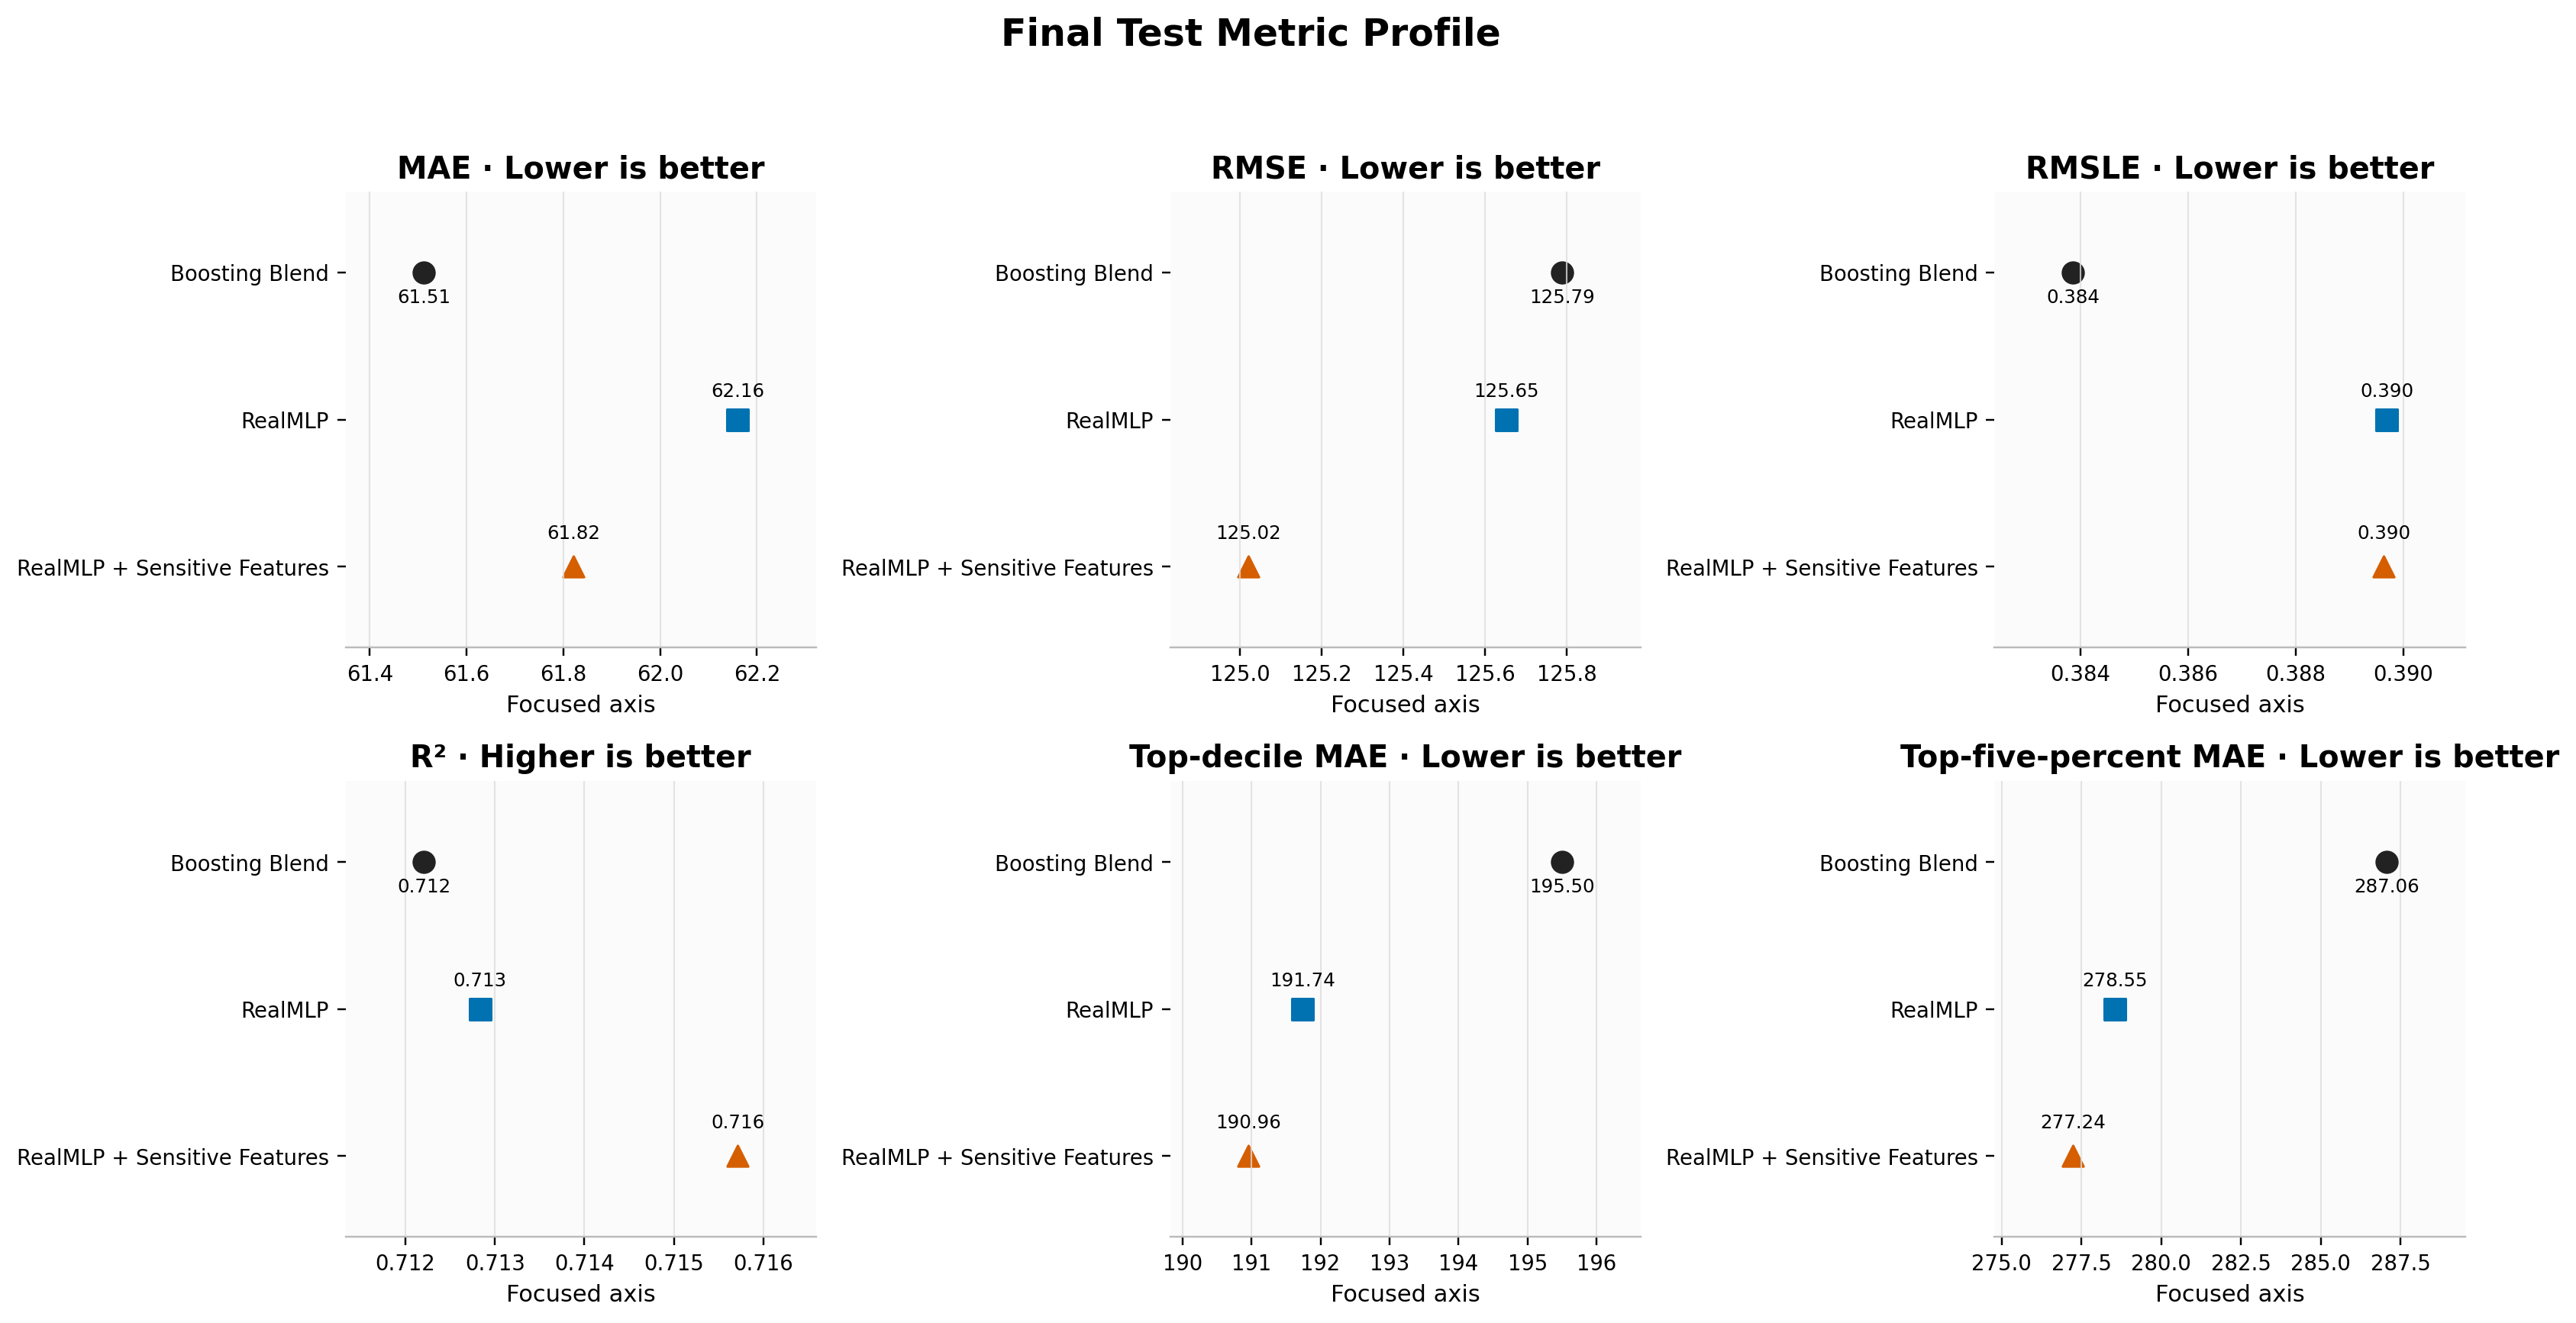

In [13]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_10_final_test_metric_profile.png'))

**Main finding:** No one model dominated every Test metric, and the differences are small on focused axes.

**Why it matters:** The profile preserves metric direction instead of hiding trade-offs in a combined score.

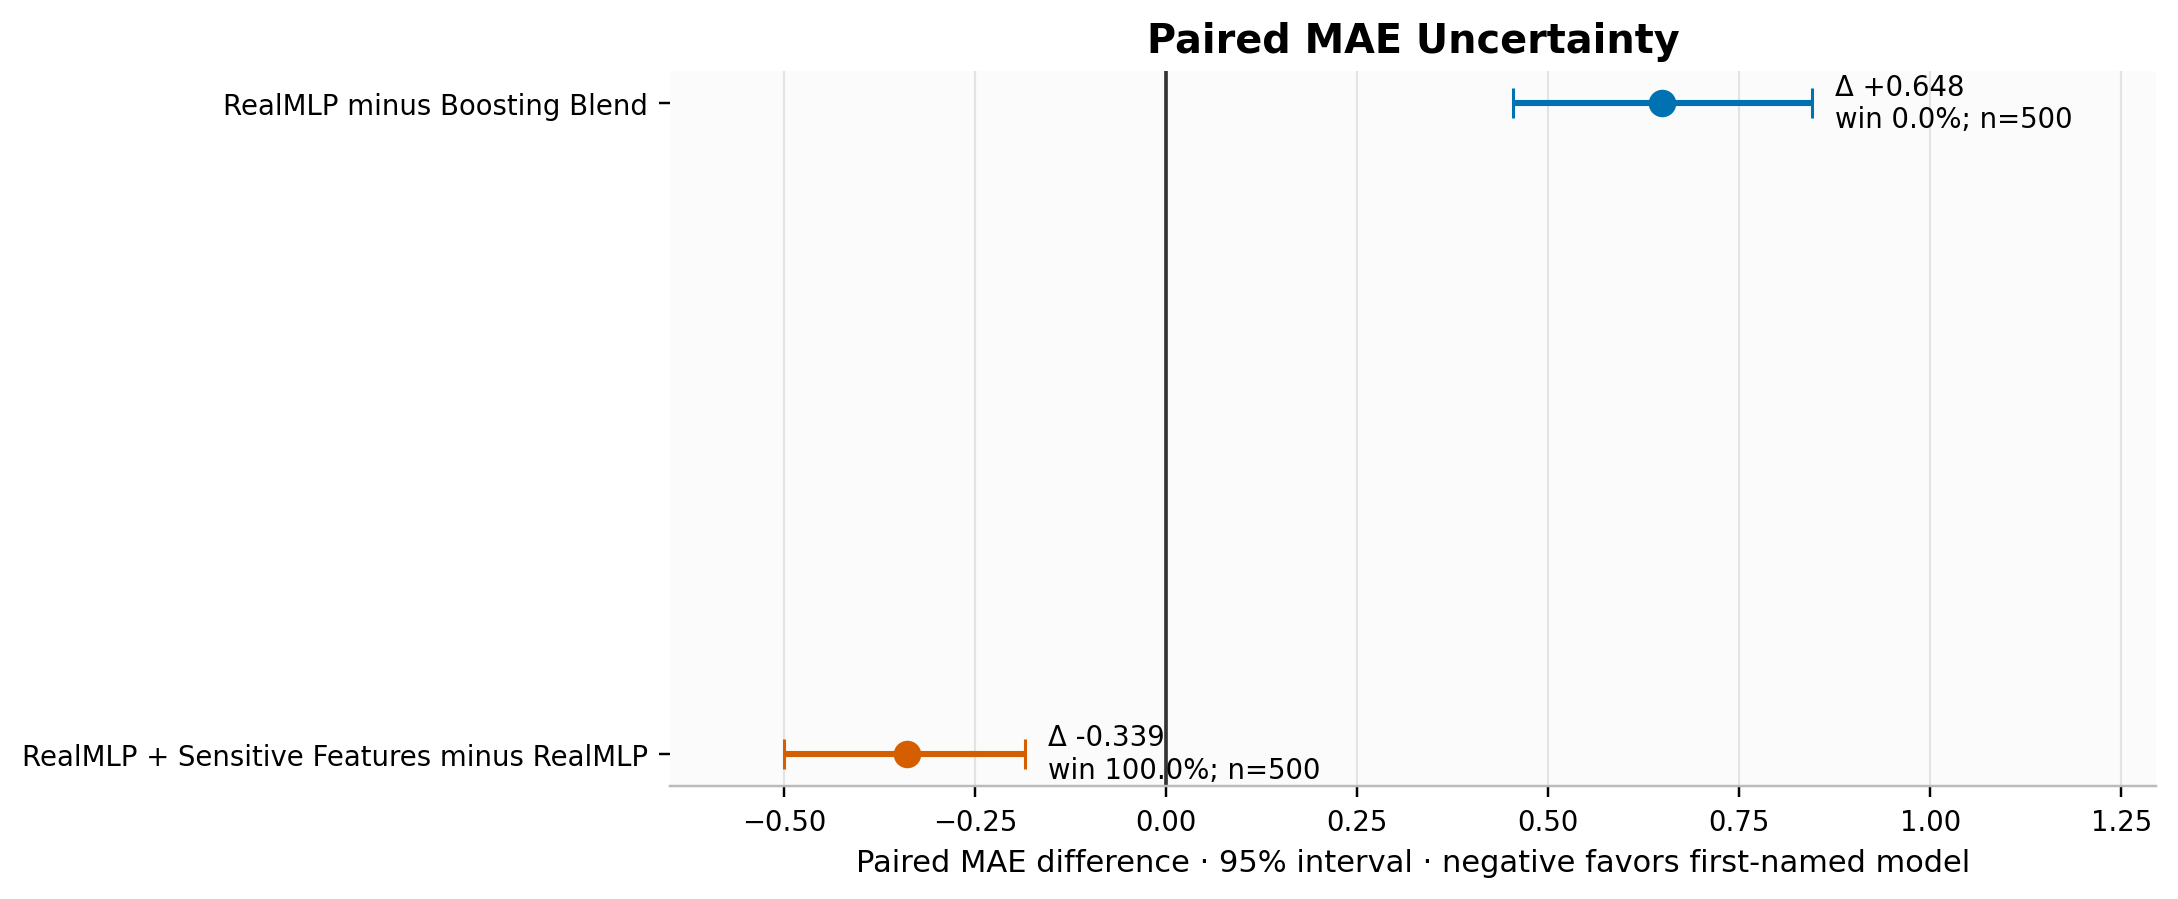

In [14]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_11_paired_mae_uncertainty.png'))

**Main finding:** RealMLP had higher MAE than Boosting Blend, while sensitive Features reduced RealMLP MAE in the saved paired intervals.

**Why it matters:** These intervals describe paired Test differences and do not perform model selection.

**Table 3 — Final Test Metrics**

In [15]:
import pandas as pd
from IPython.display import display
_table = pd.read_csv('artifacts/results/stage9_visual_summary/stage9_visual_summary_final_metrics.csv')
display(_table.style.hide(axis='index').format(precision=3))

Model,MAE,RMSE,R²,RMSLE,Mean Signed Error,P90 Absolute Error,Top-decile MAE,Top-five-percent MAE
Boosting Blend,61.512,125.788,0.712,0.384,-9.554,131.508,195.498,287.064
RealMLP,62.160,125.651,0.713,0.390,-7.014,132.684,191.741,278.546
RealMLP + Sensitive Features,61.821,125.020,0.716,0.390,-6.441,131.475,190.956,277.236


## 7. Ensemble Analysis

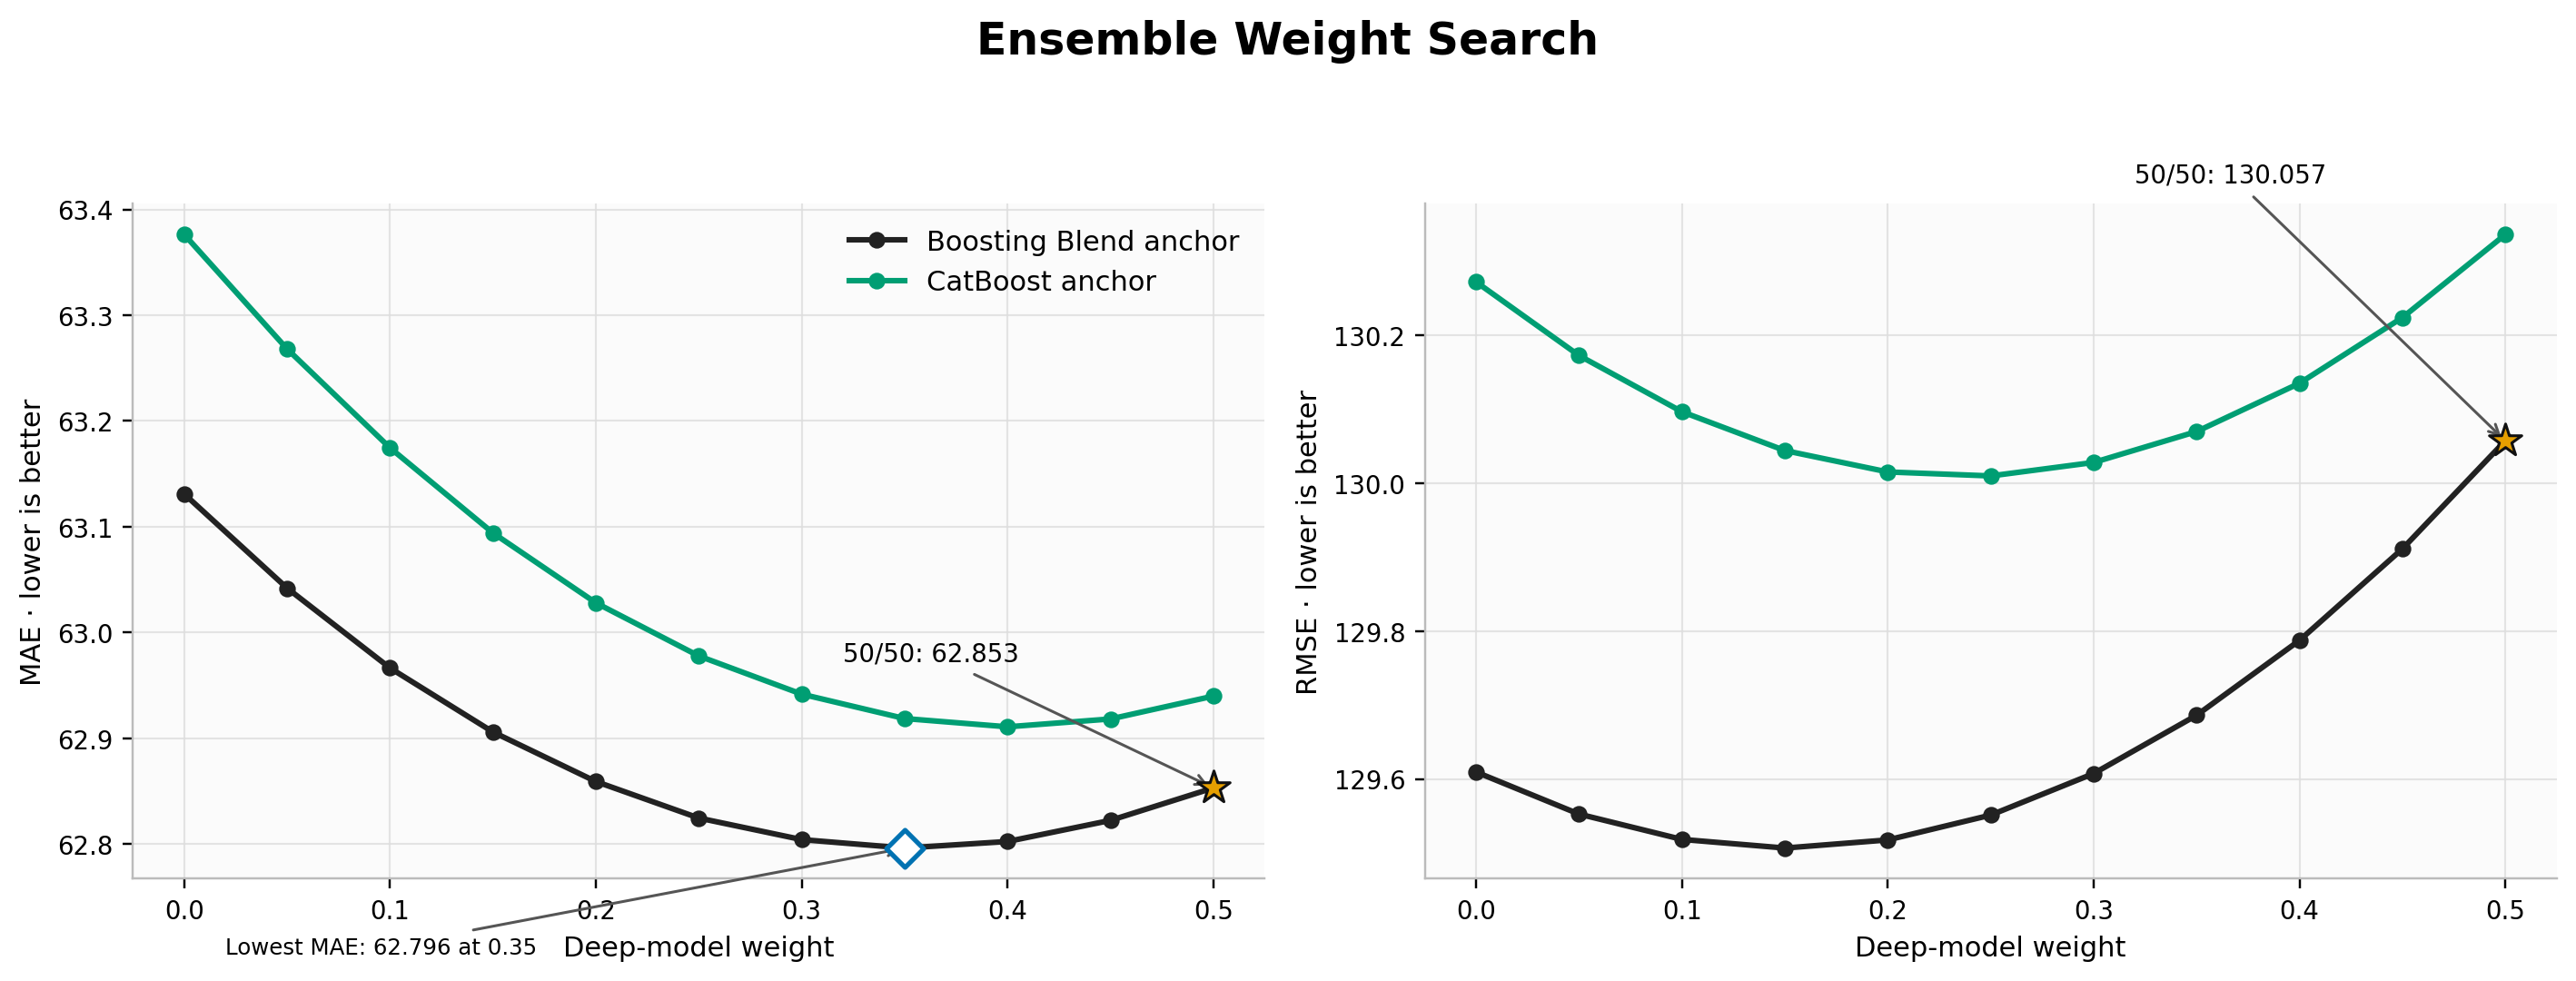

In [16]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_12_ensemble_weight_search.png'))

**Main finding:** Several blend-anchor weights improved MAE, with the selected 50/50 design marked explicitly.

**Why it matters:** The full grid shows why one metric alone was insufficient for acceptance.

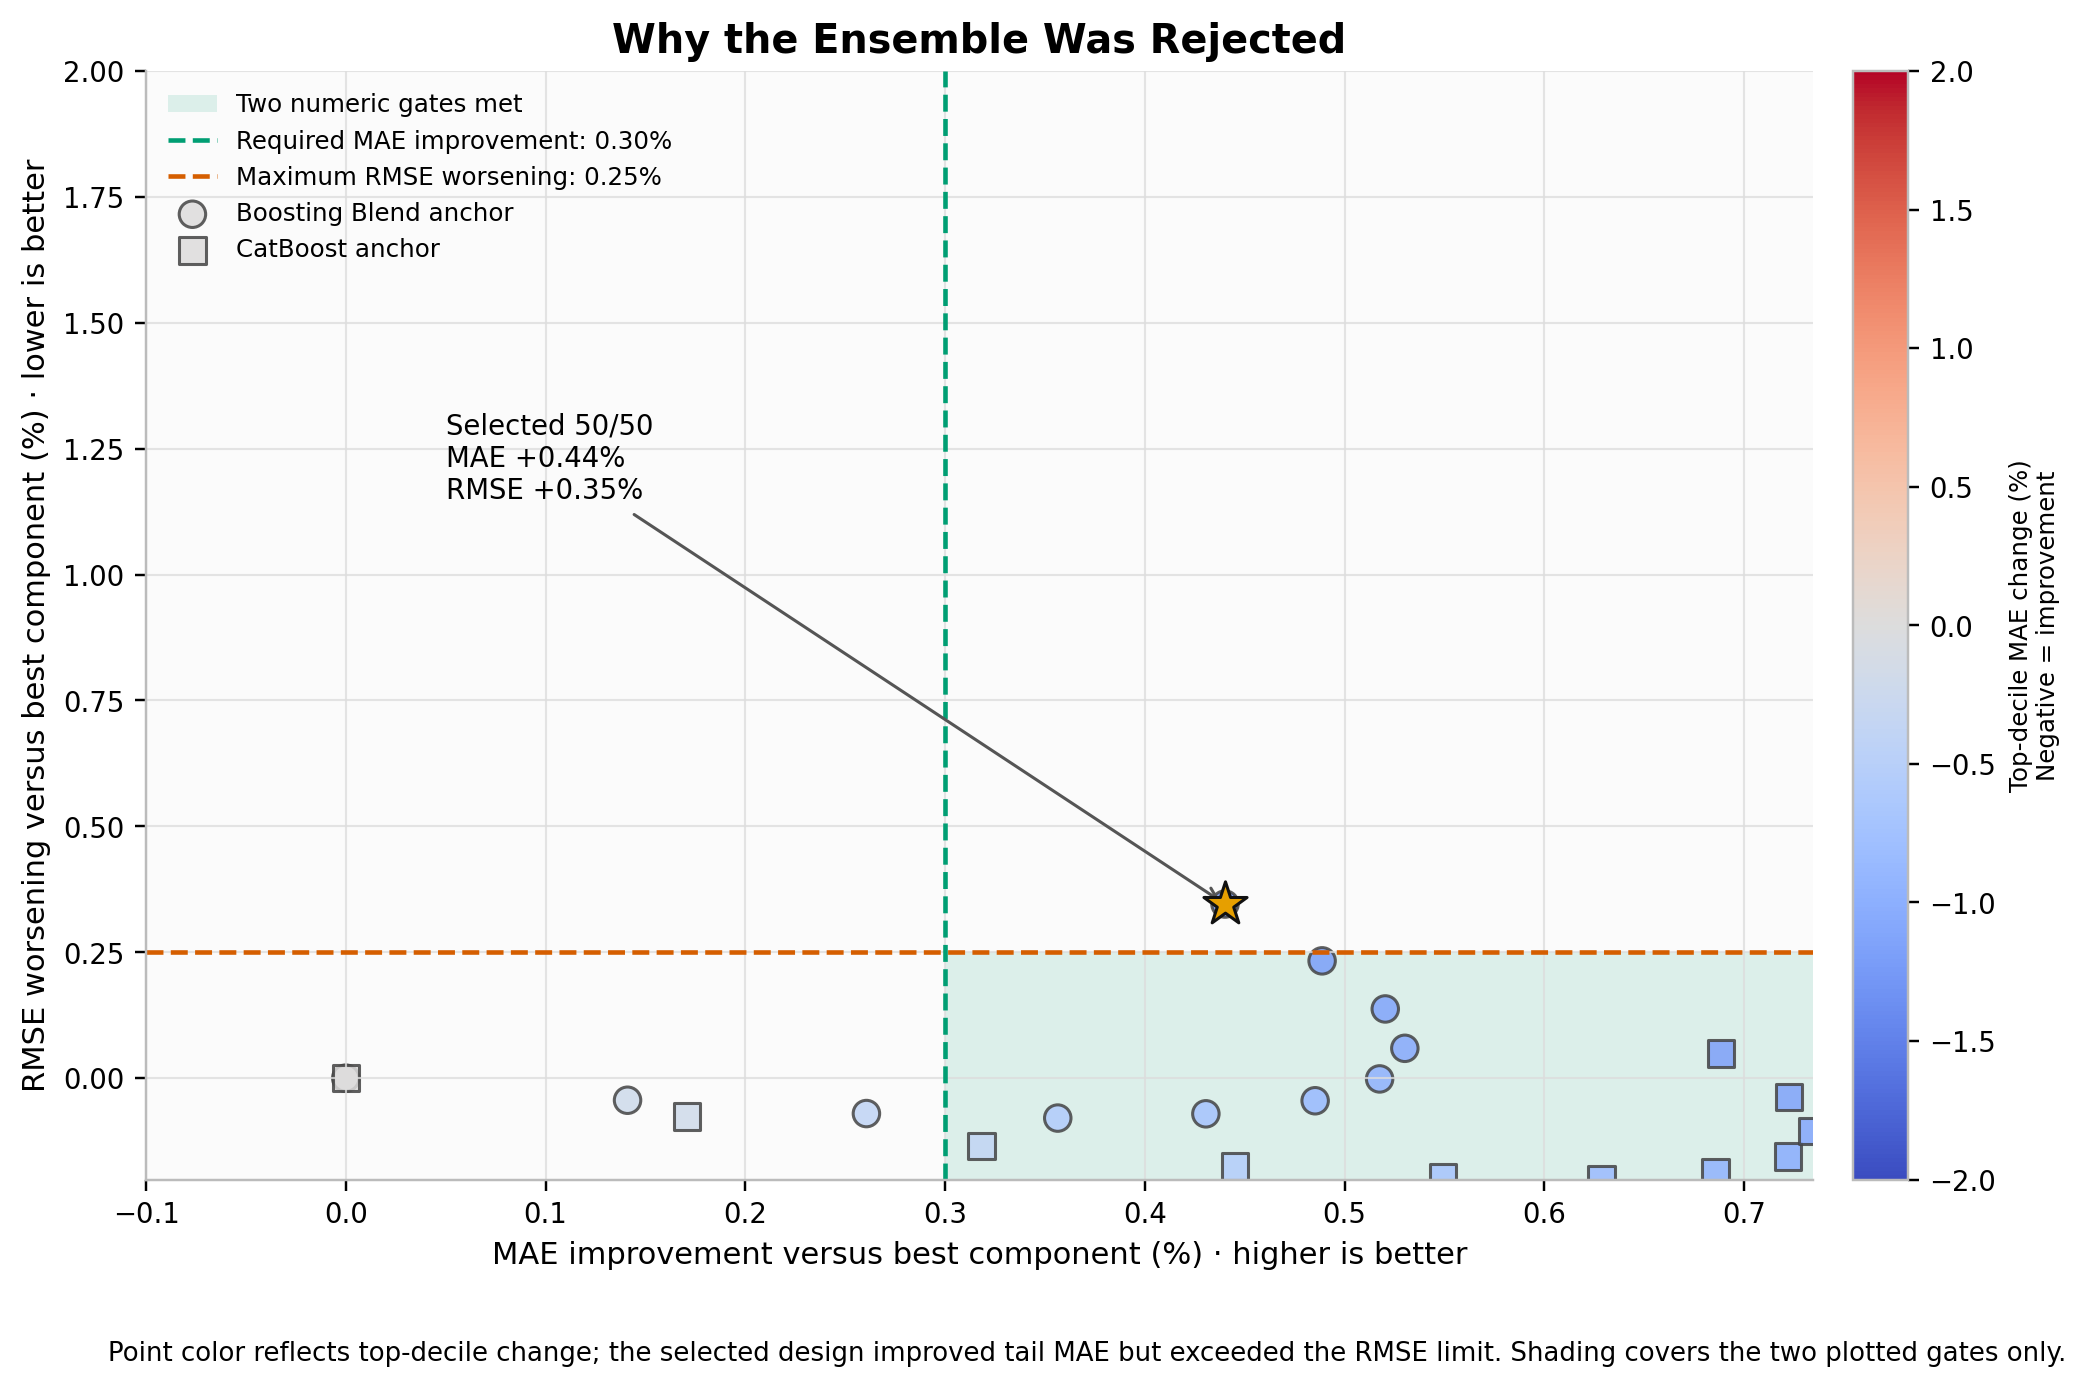

In [17]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_13_ensemble_rejection_tradeoff.png'))

**Main finding:** The selected ensemble improved MAE and tail MAE but exceeded the allowed RMSE worsening limit.

**Why it matters:** The quantitative gate trade-off explains why the ensemble was not used.

**Table 5 — Ensemble Acceptance Evidence**

In [18]:
import pandas as pd
from IPython.display import display
_table = pd.read_csv('artifacts/results/stage9_visual_summary/stage9_visual_summary_ensemble_table.csv')
display(_table.style.hide(axis='index').format(precision=3))

Deep weight,Boosting weight,MAE improvement (%),RMSE worsening (%),Tail change (%),Bootstrap interval,Gate result
0.500,0.500,0.440,0.346,-1.222,"[-0.471, -0.069]",Not accepted — RMSE limit exceeded


## 8. Error Analysis

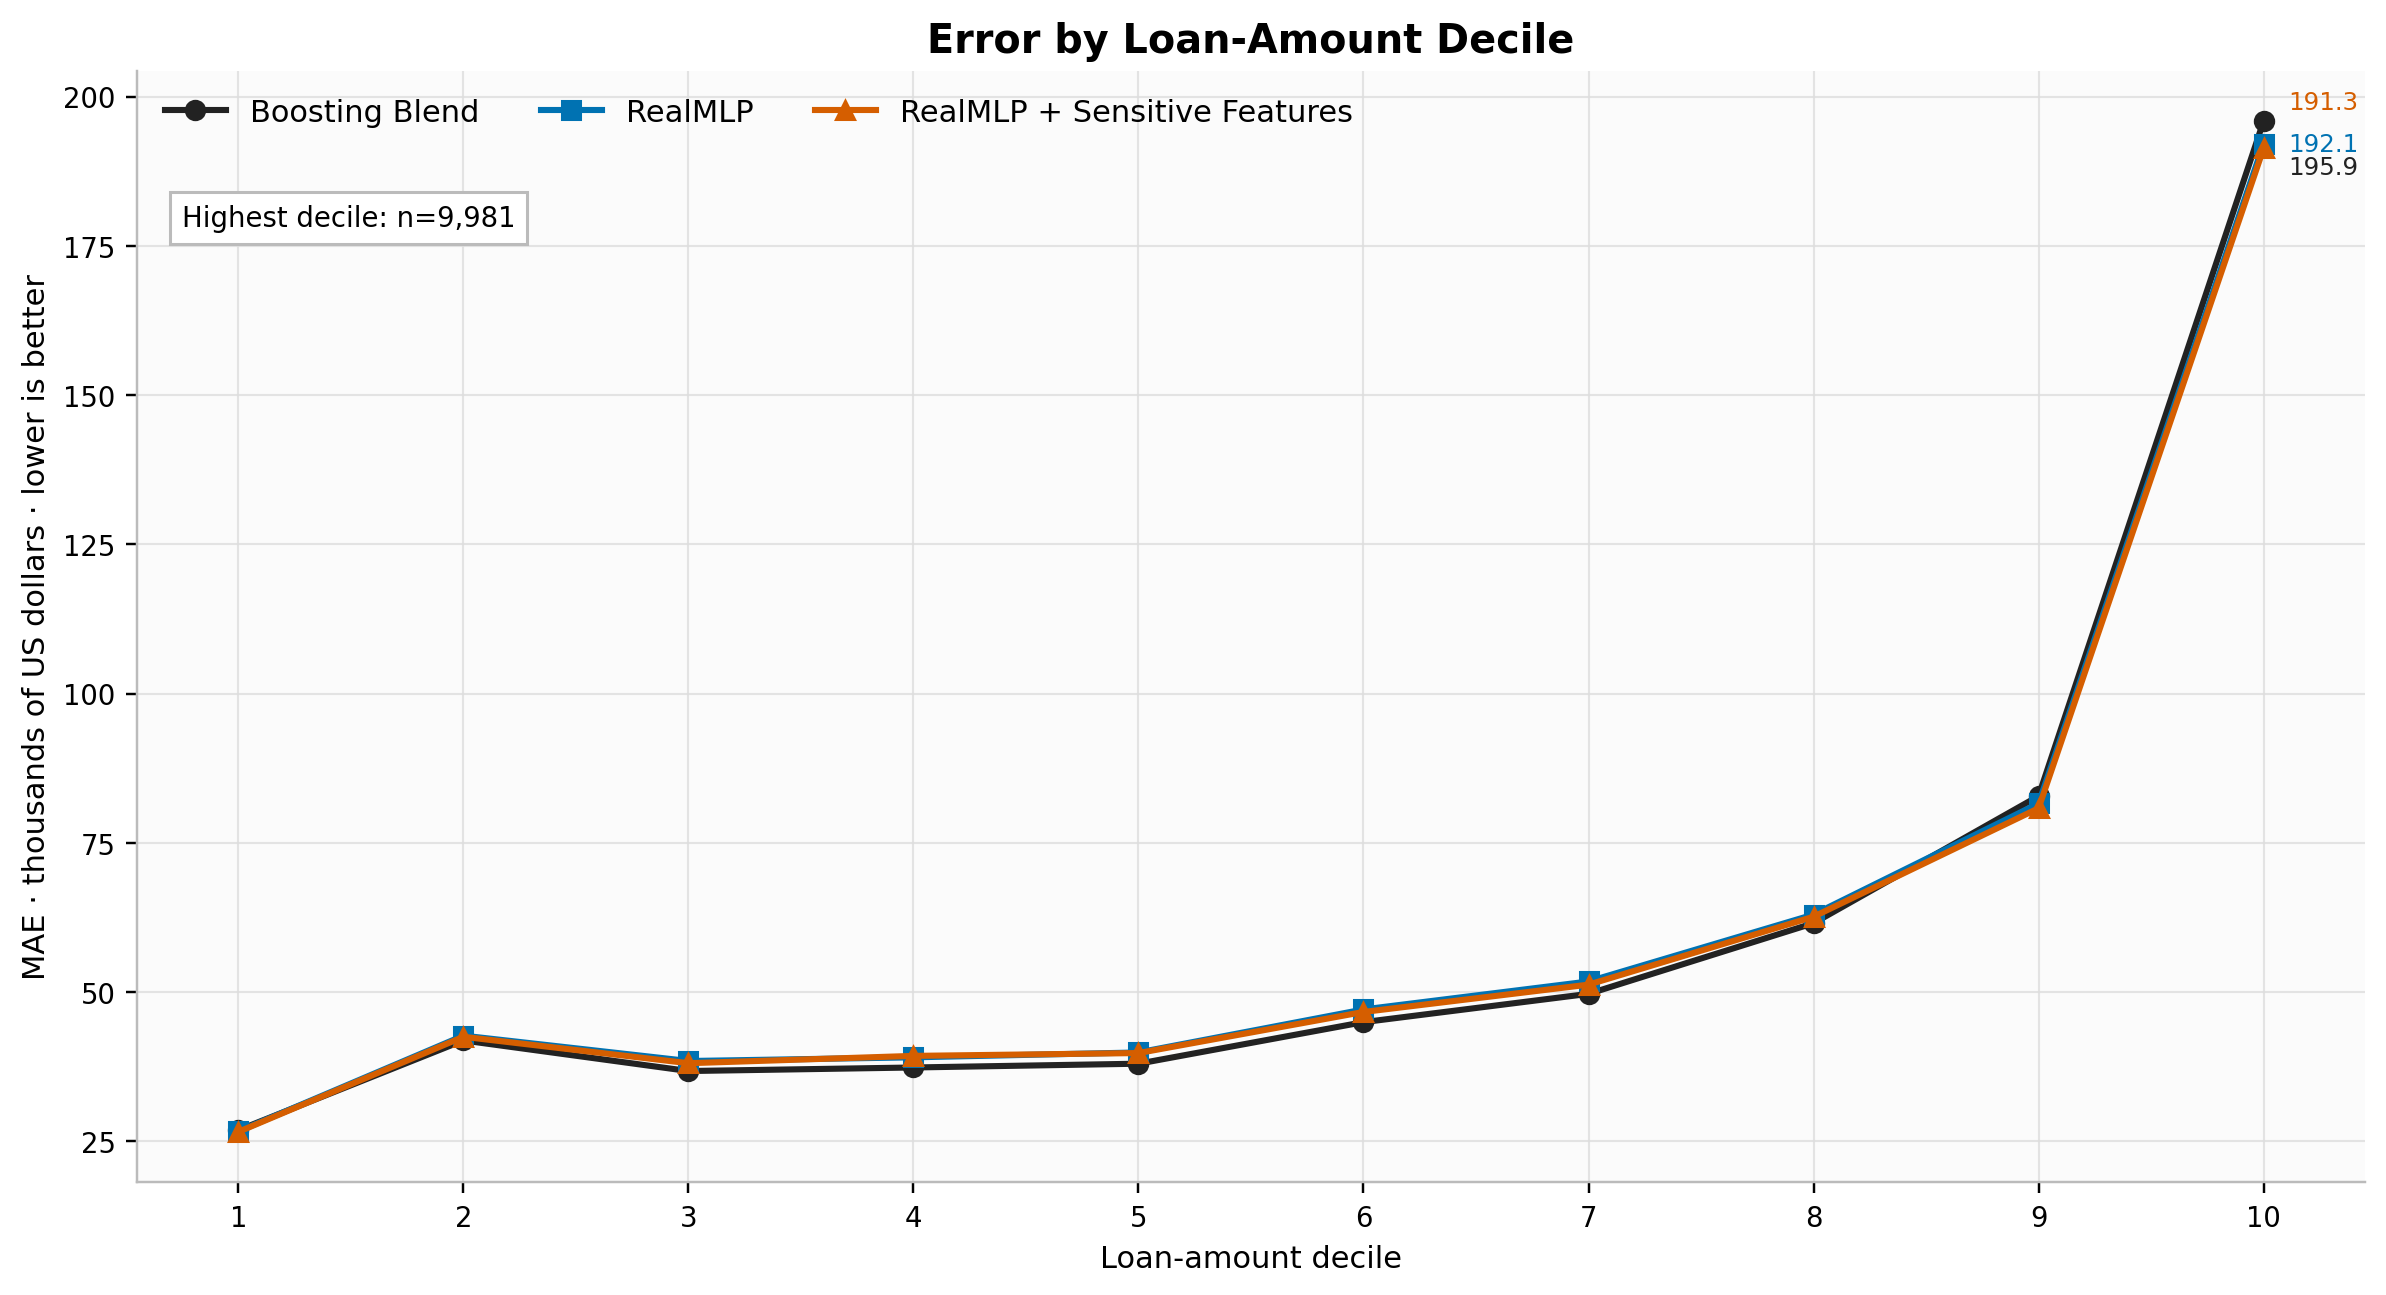

In [19]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_14_error_by_target_decile.png'))

**Main finding:** MAE rises sharply in the highest loan-amount decile.

**Why it matters:** Large-loan behavior is the main error-tail concern.

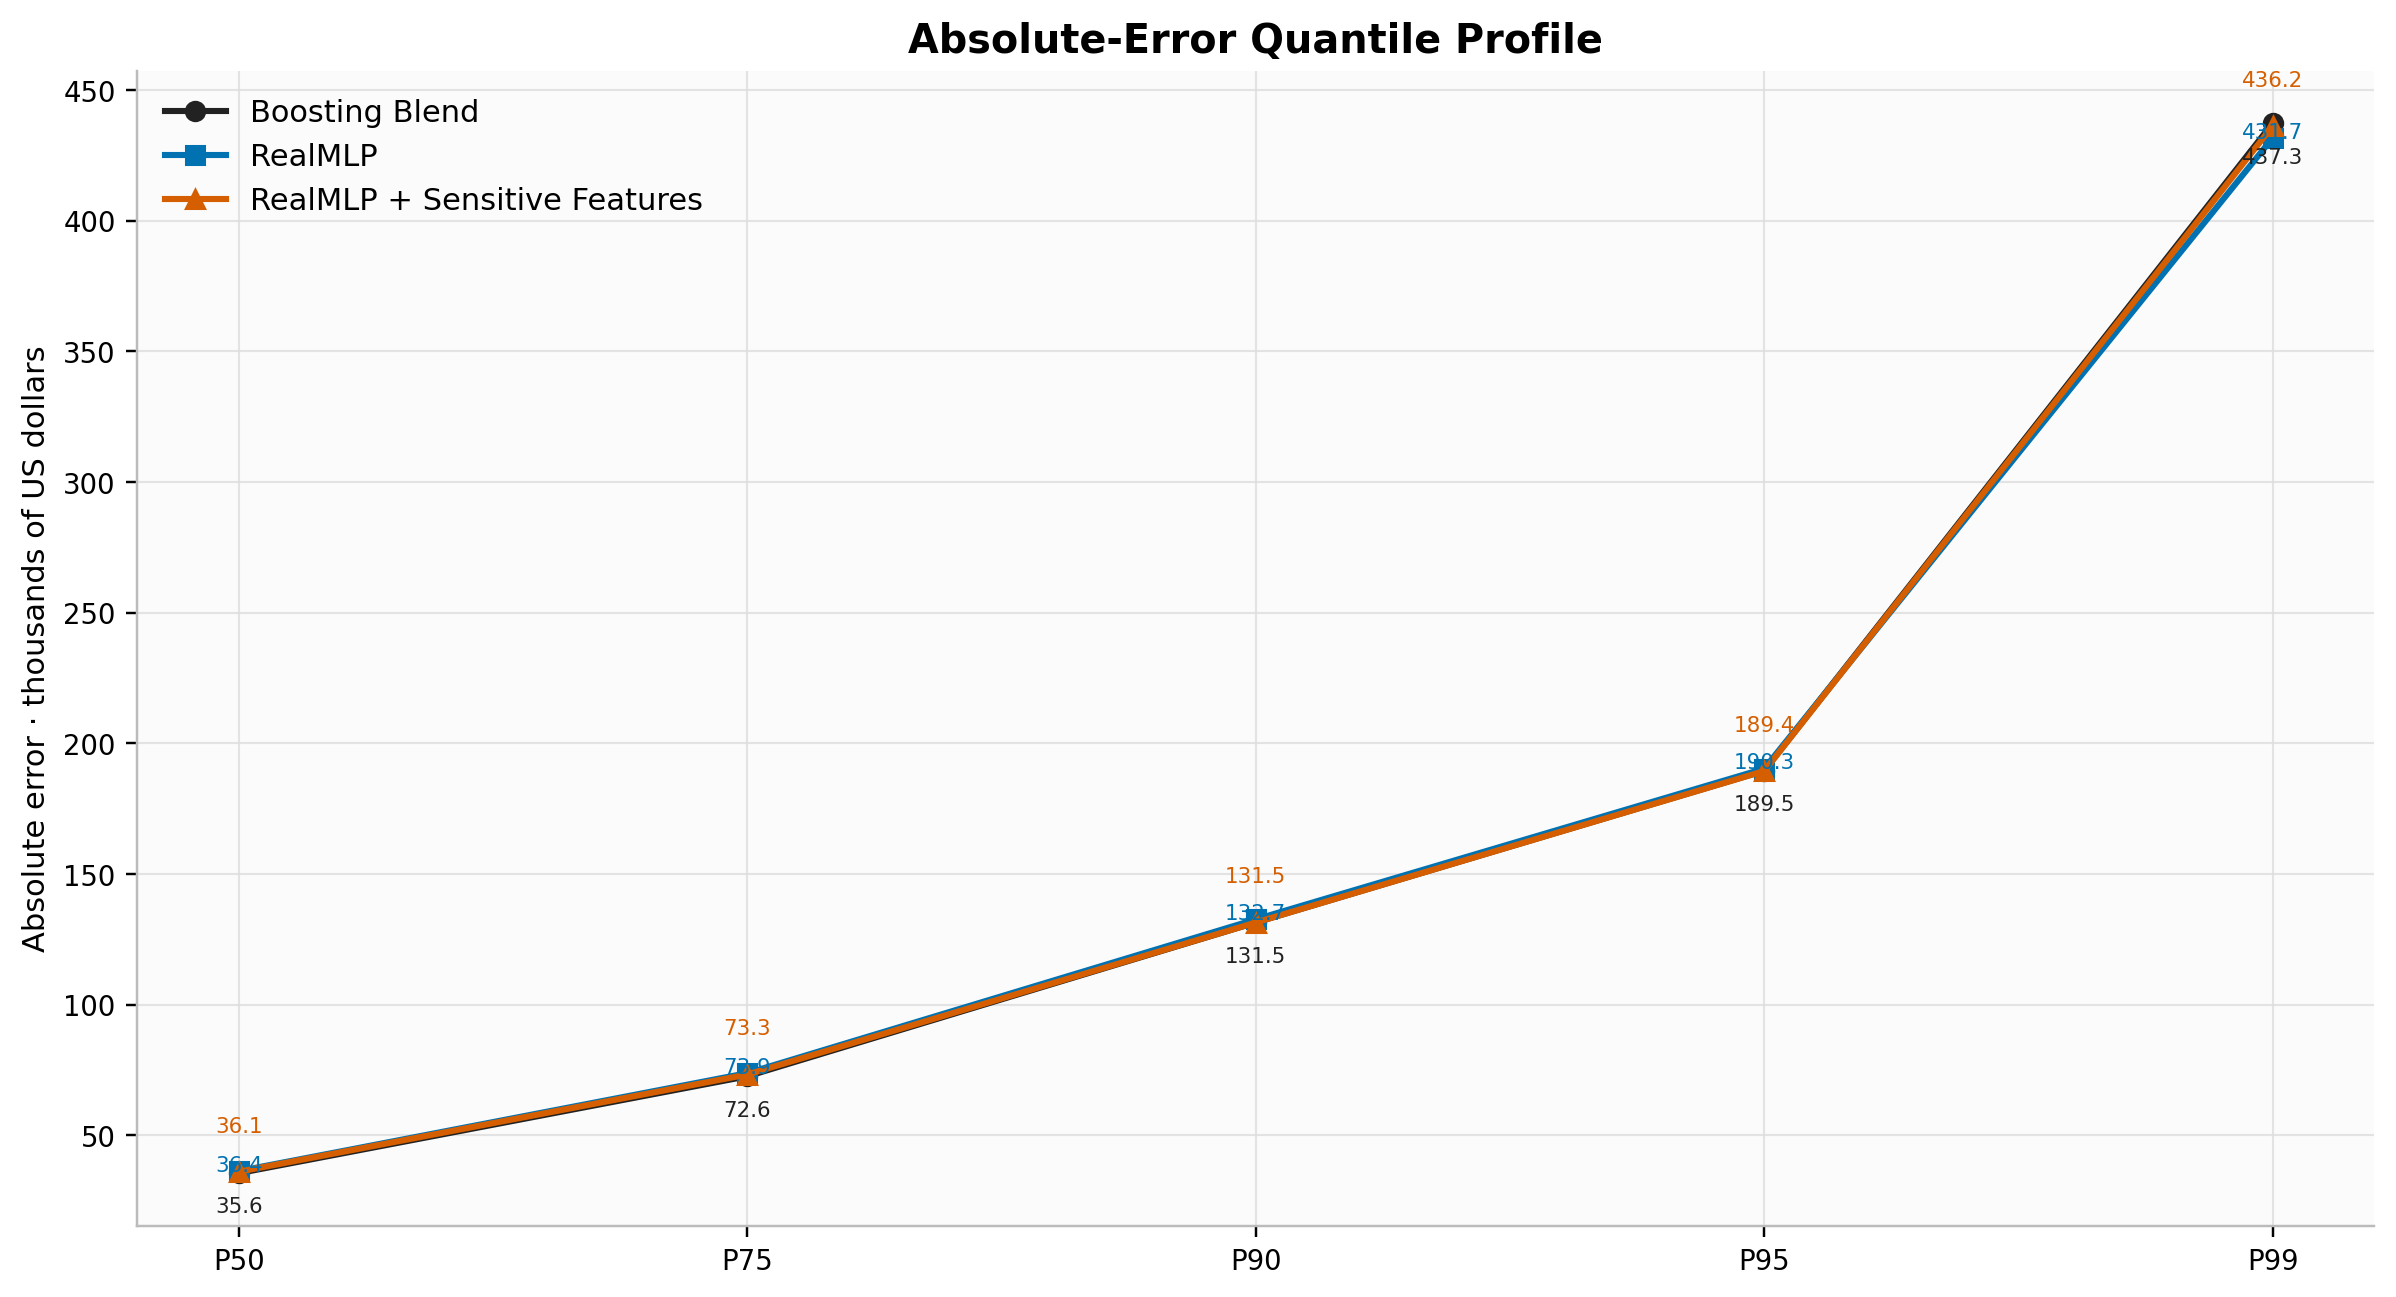

In [20]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_15_absolute_error_quantiles.png'))

**Main finding:** P99 errors exceed 430 thousand dollars for every model.

**Why it matters:** The profile shows tail risk without extreme maxima.

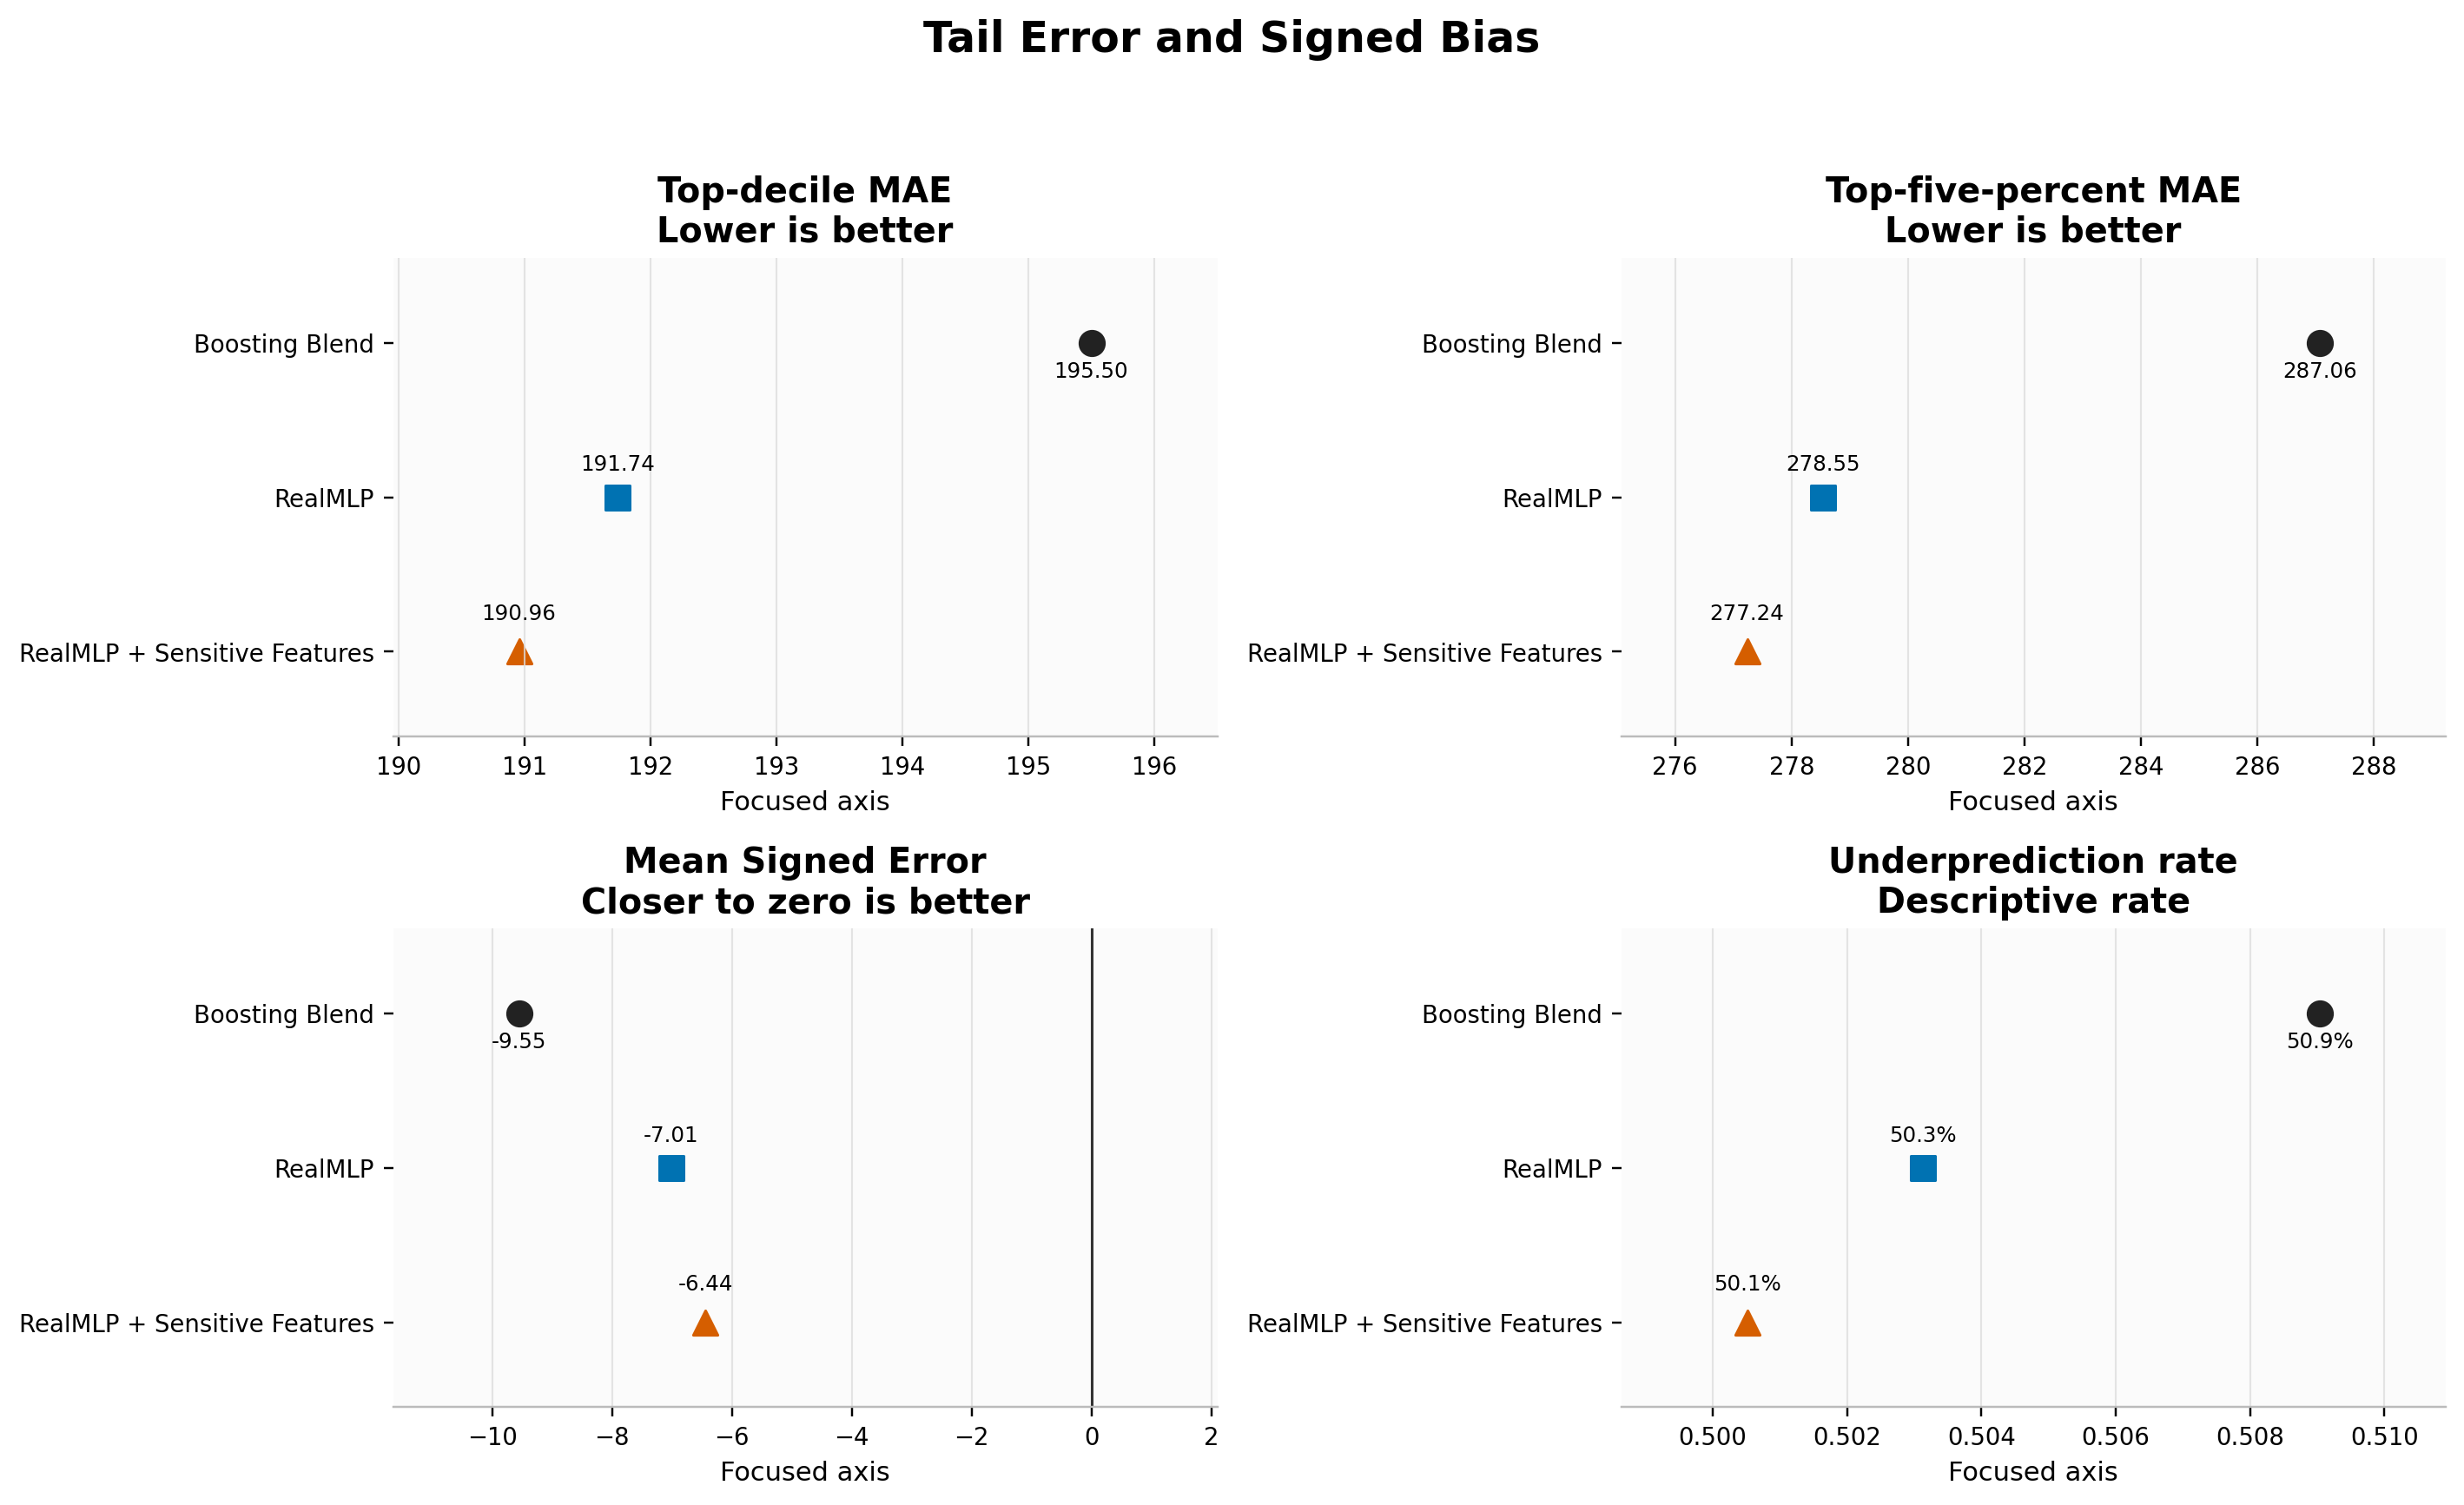

In [21]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_16_tail_error_signed_bias.png'))

**Main finding:** RealMLP variants reduce large-loan MAE and negative signed bias.

**Why it matters:** Signed error is judged by distance from zero.

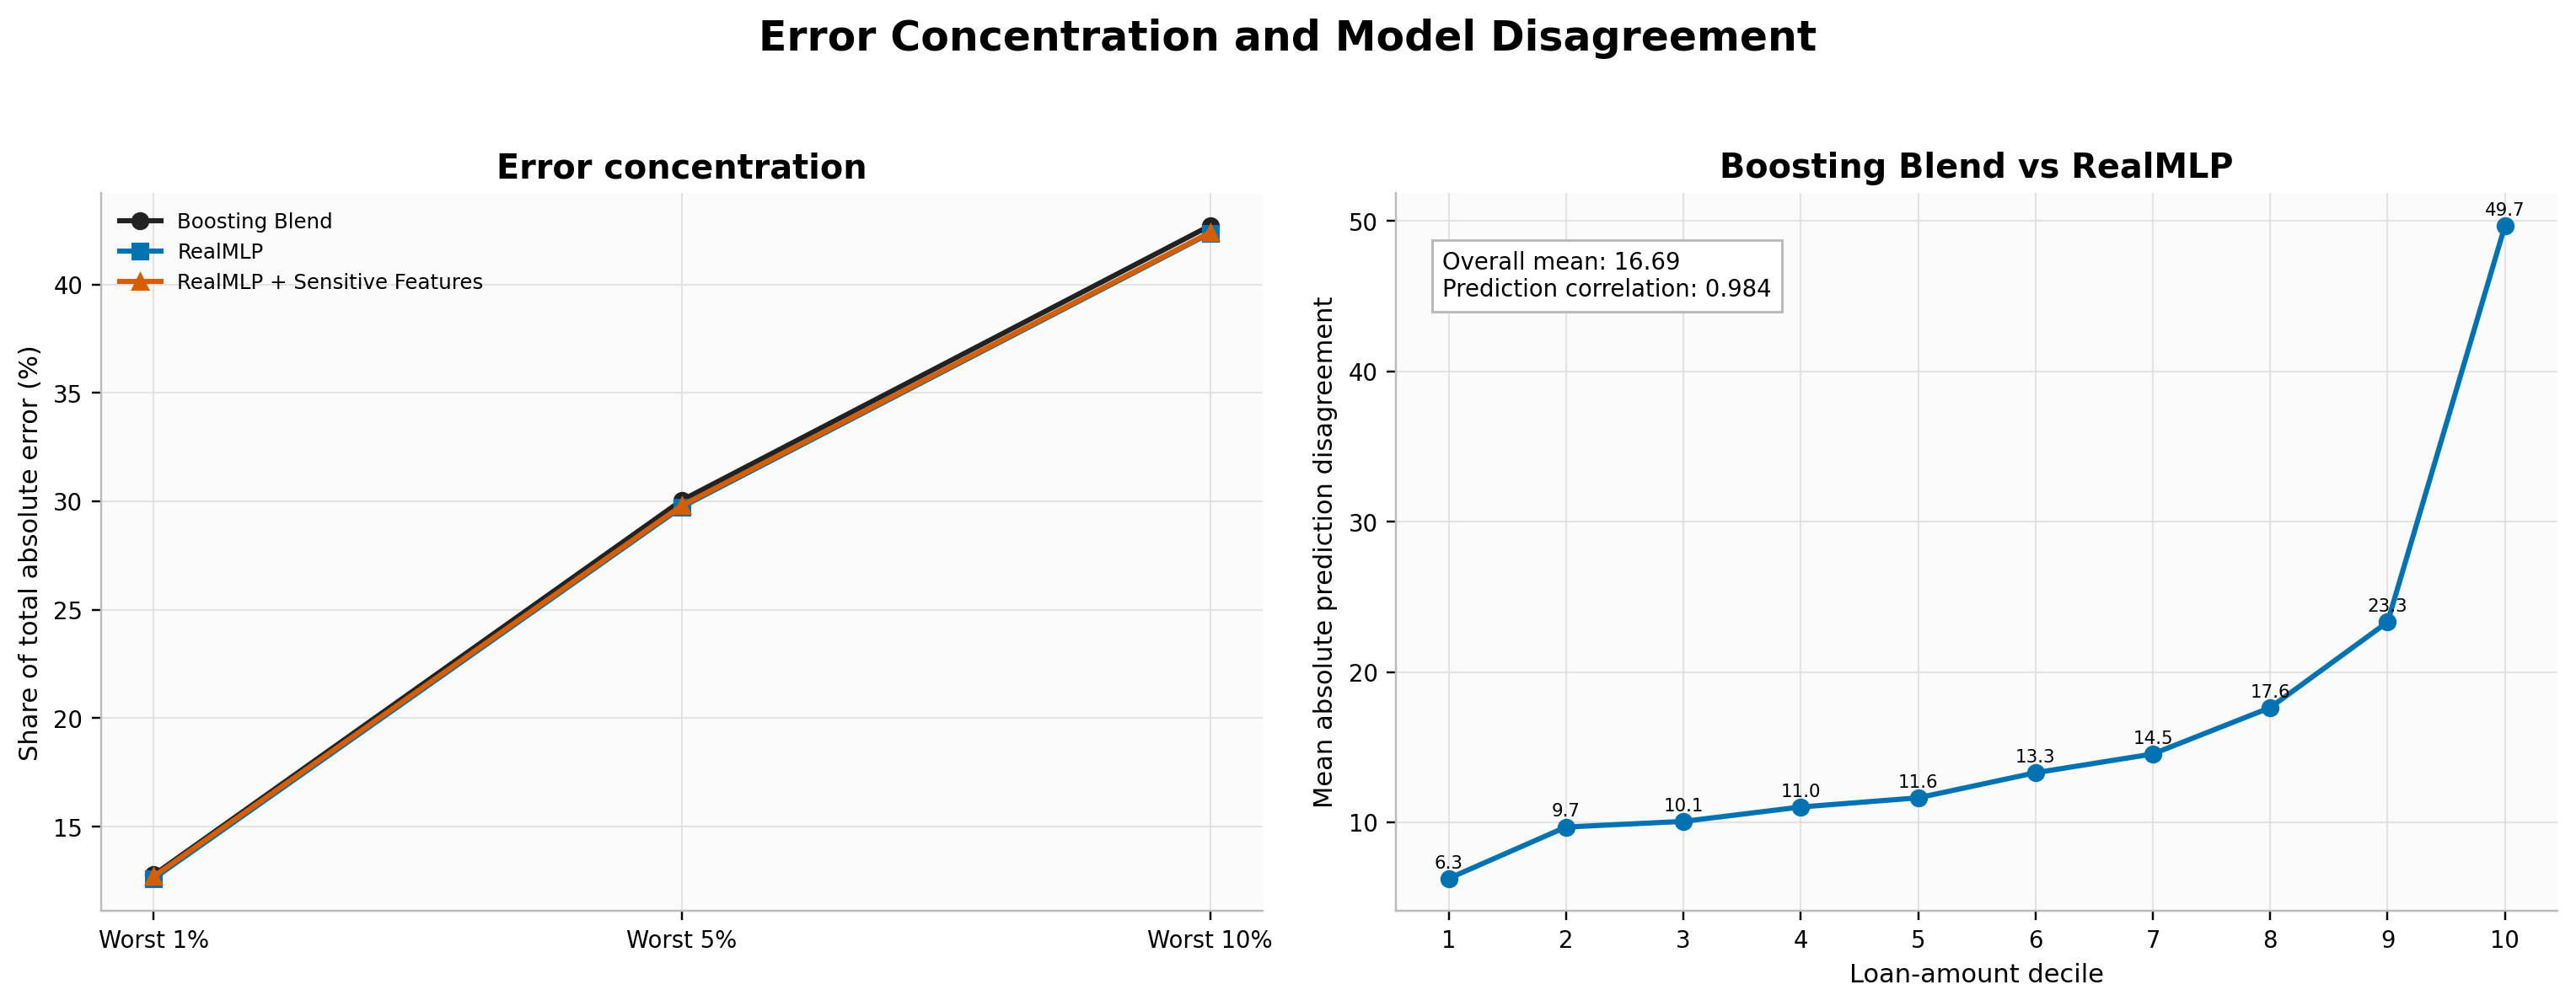

In [22]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_17_error_concentration_disagreement.png'))

**Main finding:** The worst 10% contributes over two-fifths of absolute error, while disagreement grows by decile.

**Why it matters:** Both diagnostics identify difficult large-loan cases.

**Table 6 — Error Summary**

In [23]:
import pandas as pd
from IPython.display import display
_table = pd.read_csv('artifacts/results/stage9_visual_summary/stage9_visual_summary_error_table.csv')
display(_table.style.hide(axis='index').format(precision=3))

Model,Median absolute error,P90,P95,P99,Top-decile MAE,Underprediction rate,Error share from worst 10% (%)
Boosting Blend,35.590,131.508,189.545,437.307,195.498,0.509,42.712
RealMLP,36.401,132.684,190.337,431.674,191.741,0.503,42.364
RealMLP + Sensitive Features,36.132,131.475,189.436,436.208,190.956,0.501,42.399


## 9. Feature Importance

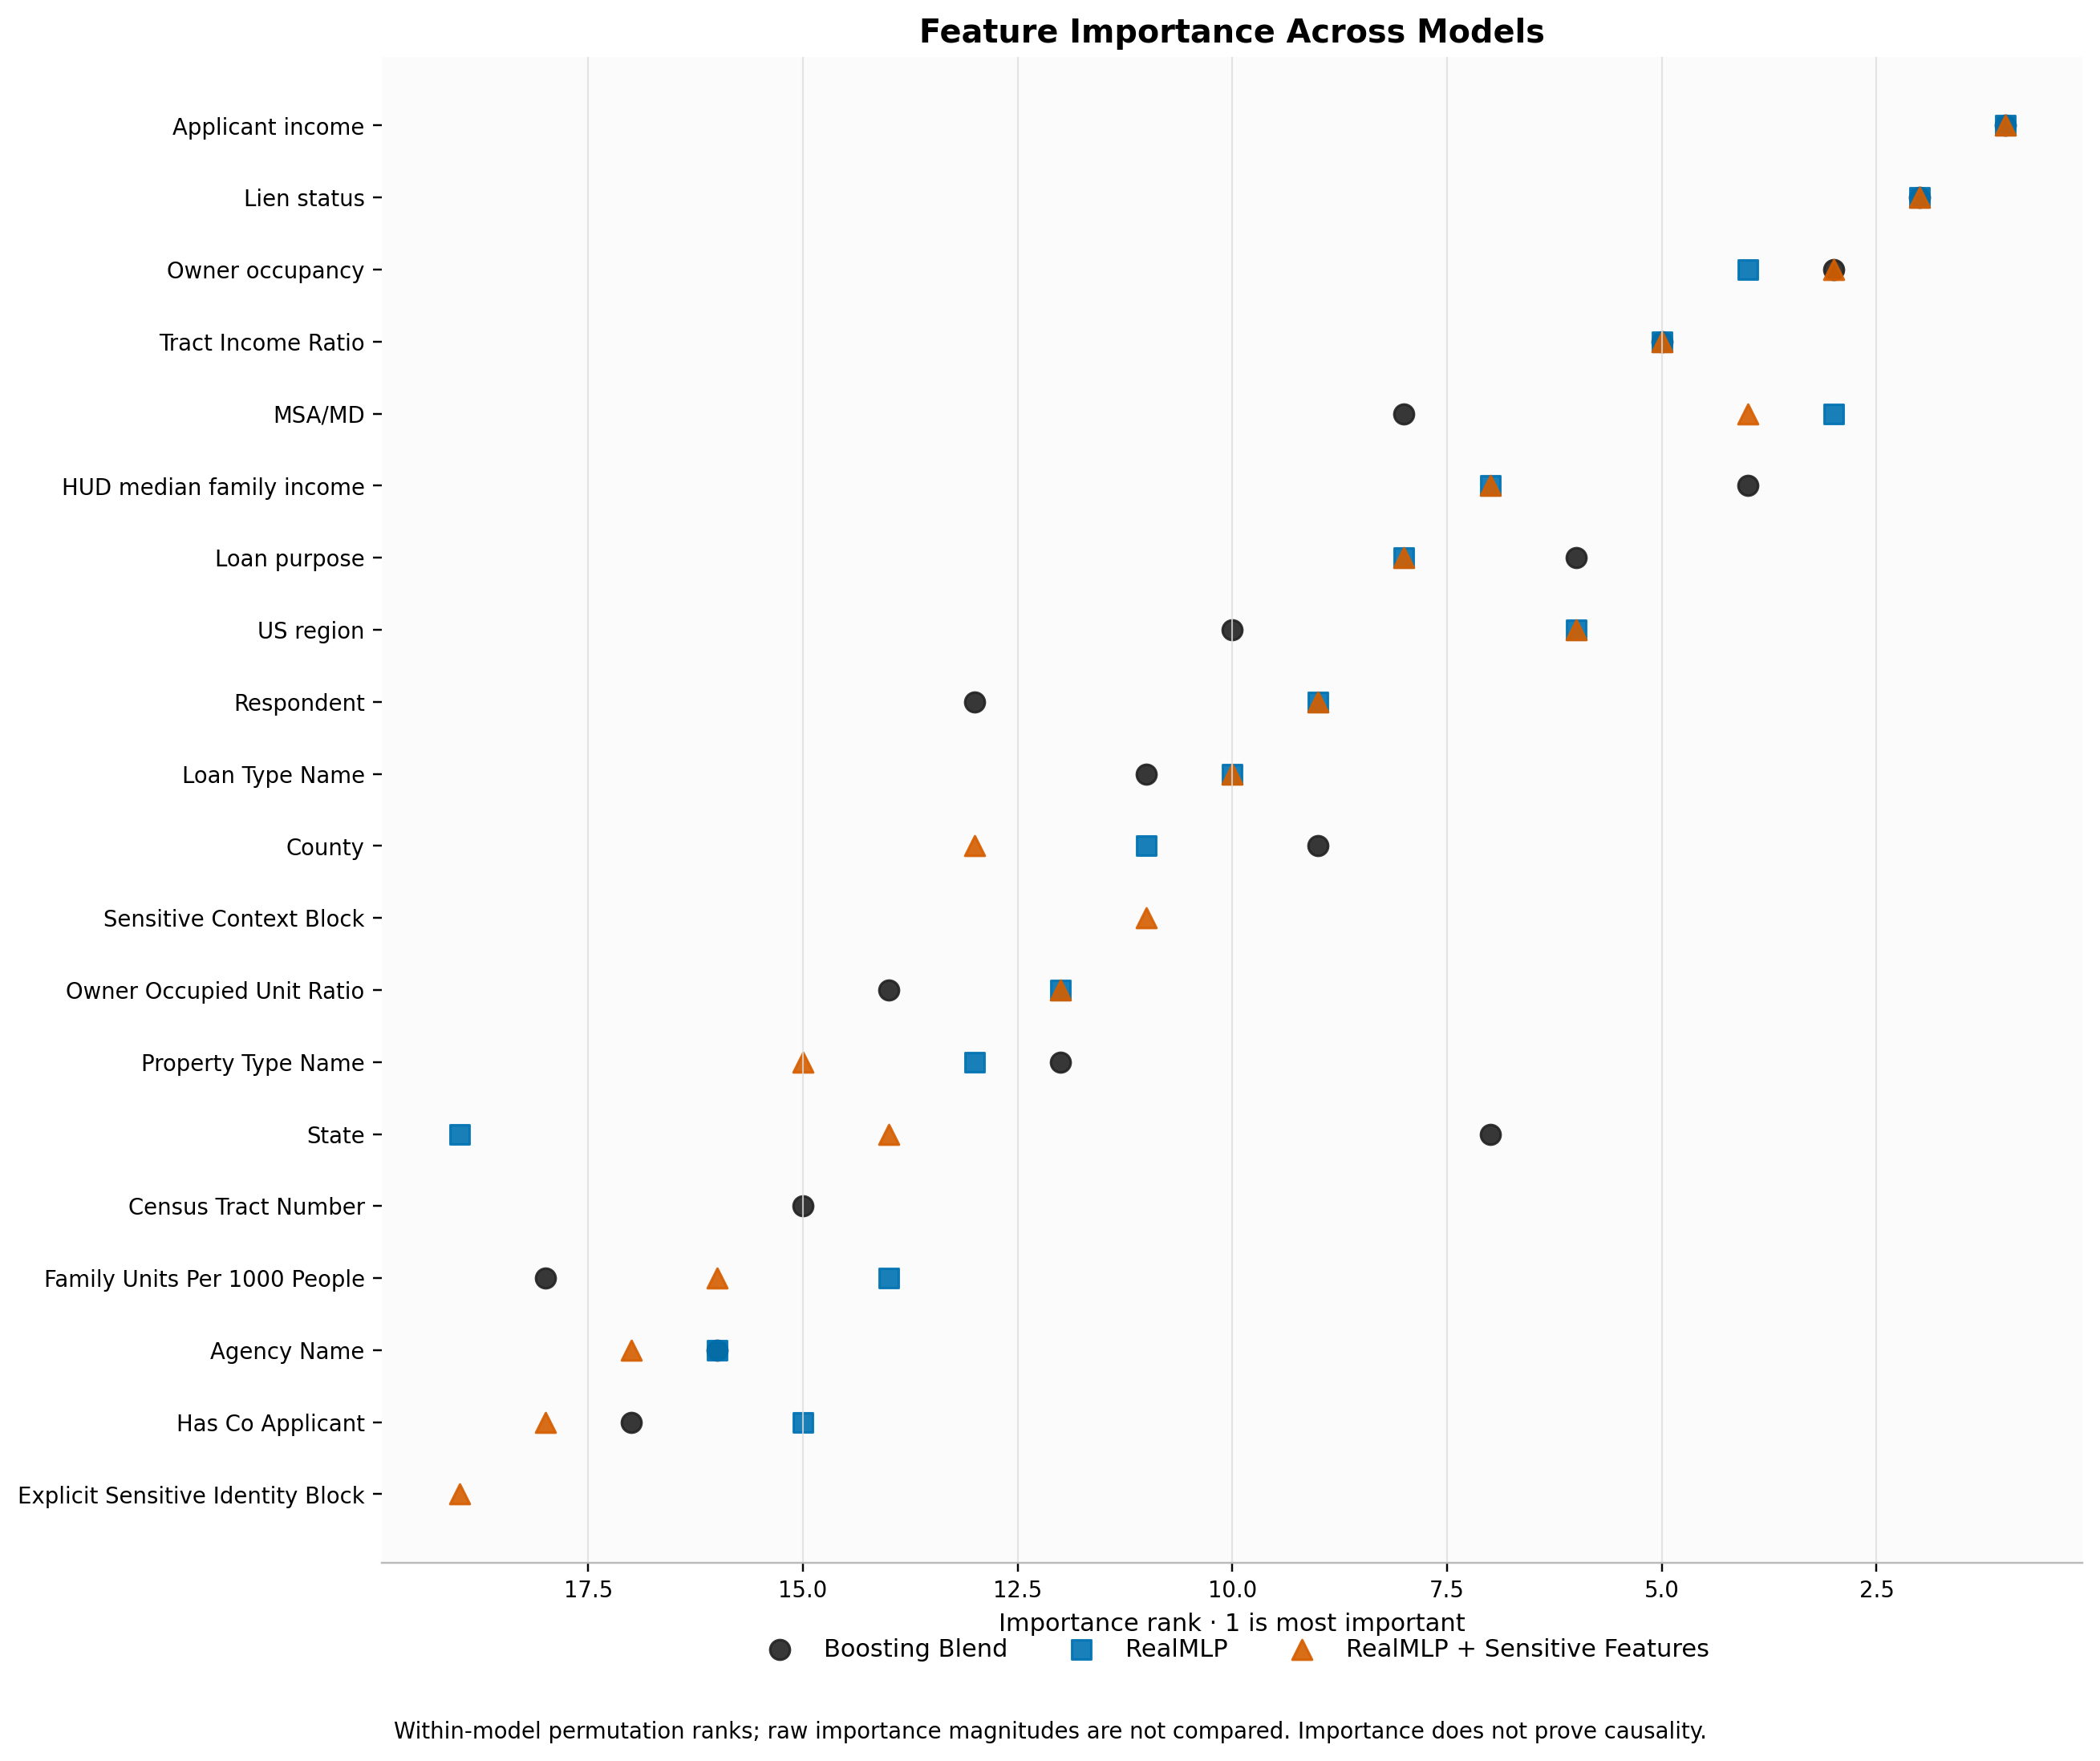

In [24]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_18_feature_importance_across_models.png'))

**Main finding:** Applicant income ranks first across all three final models, with several geography and loan-context units also prominent.

**Why it matters:** Within-model ranks support comparison without mixing incompatible raw importance scales.

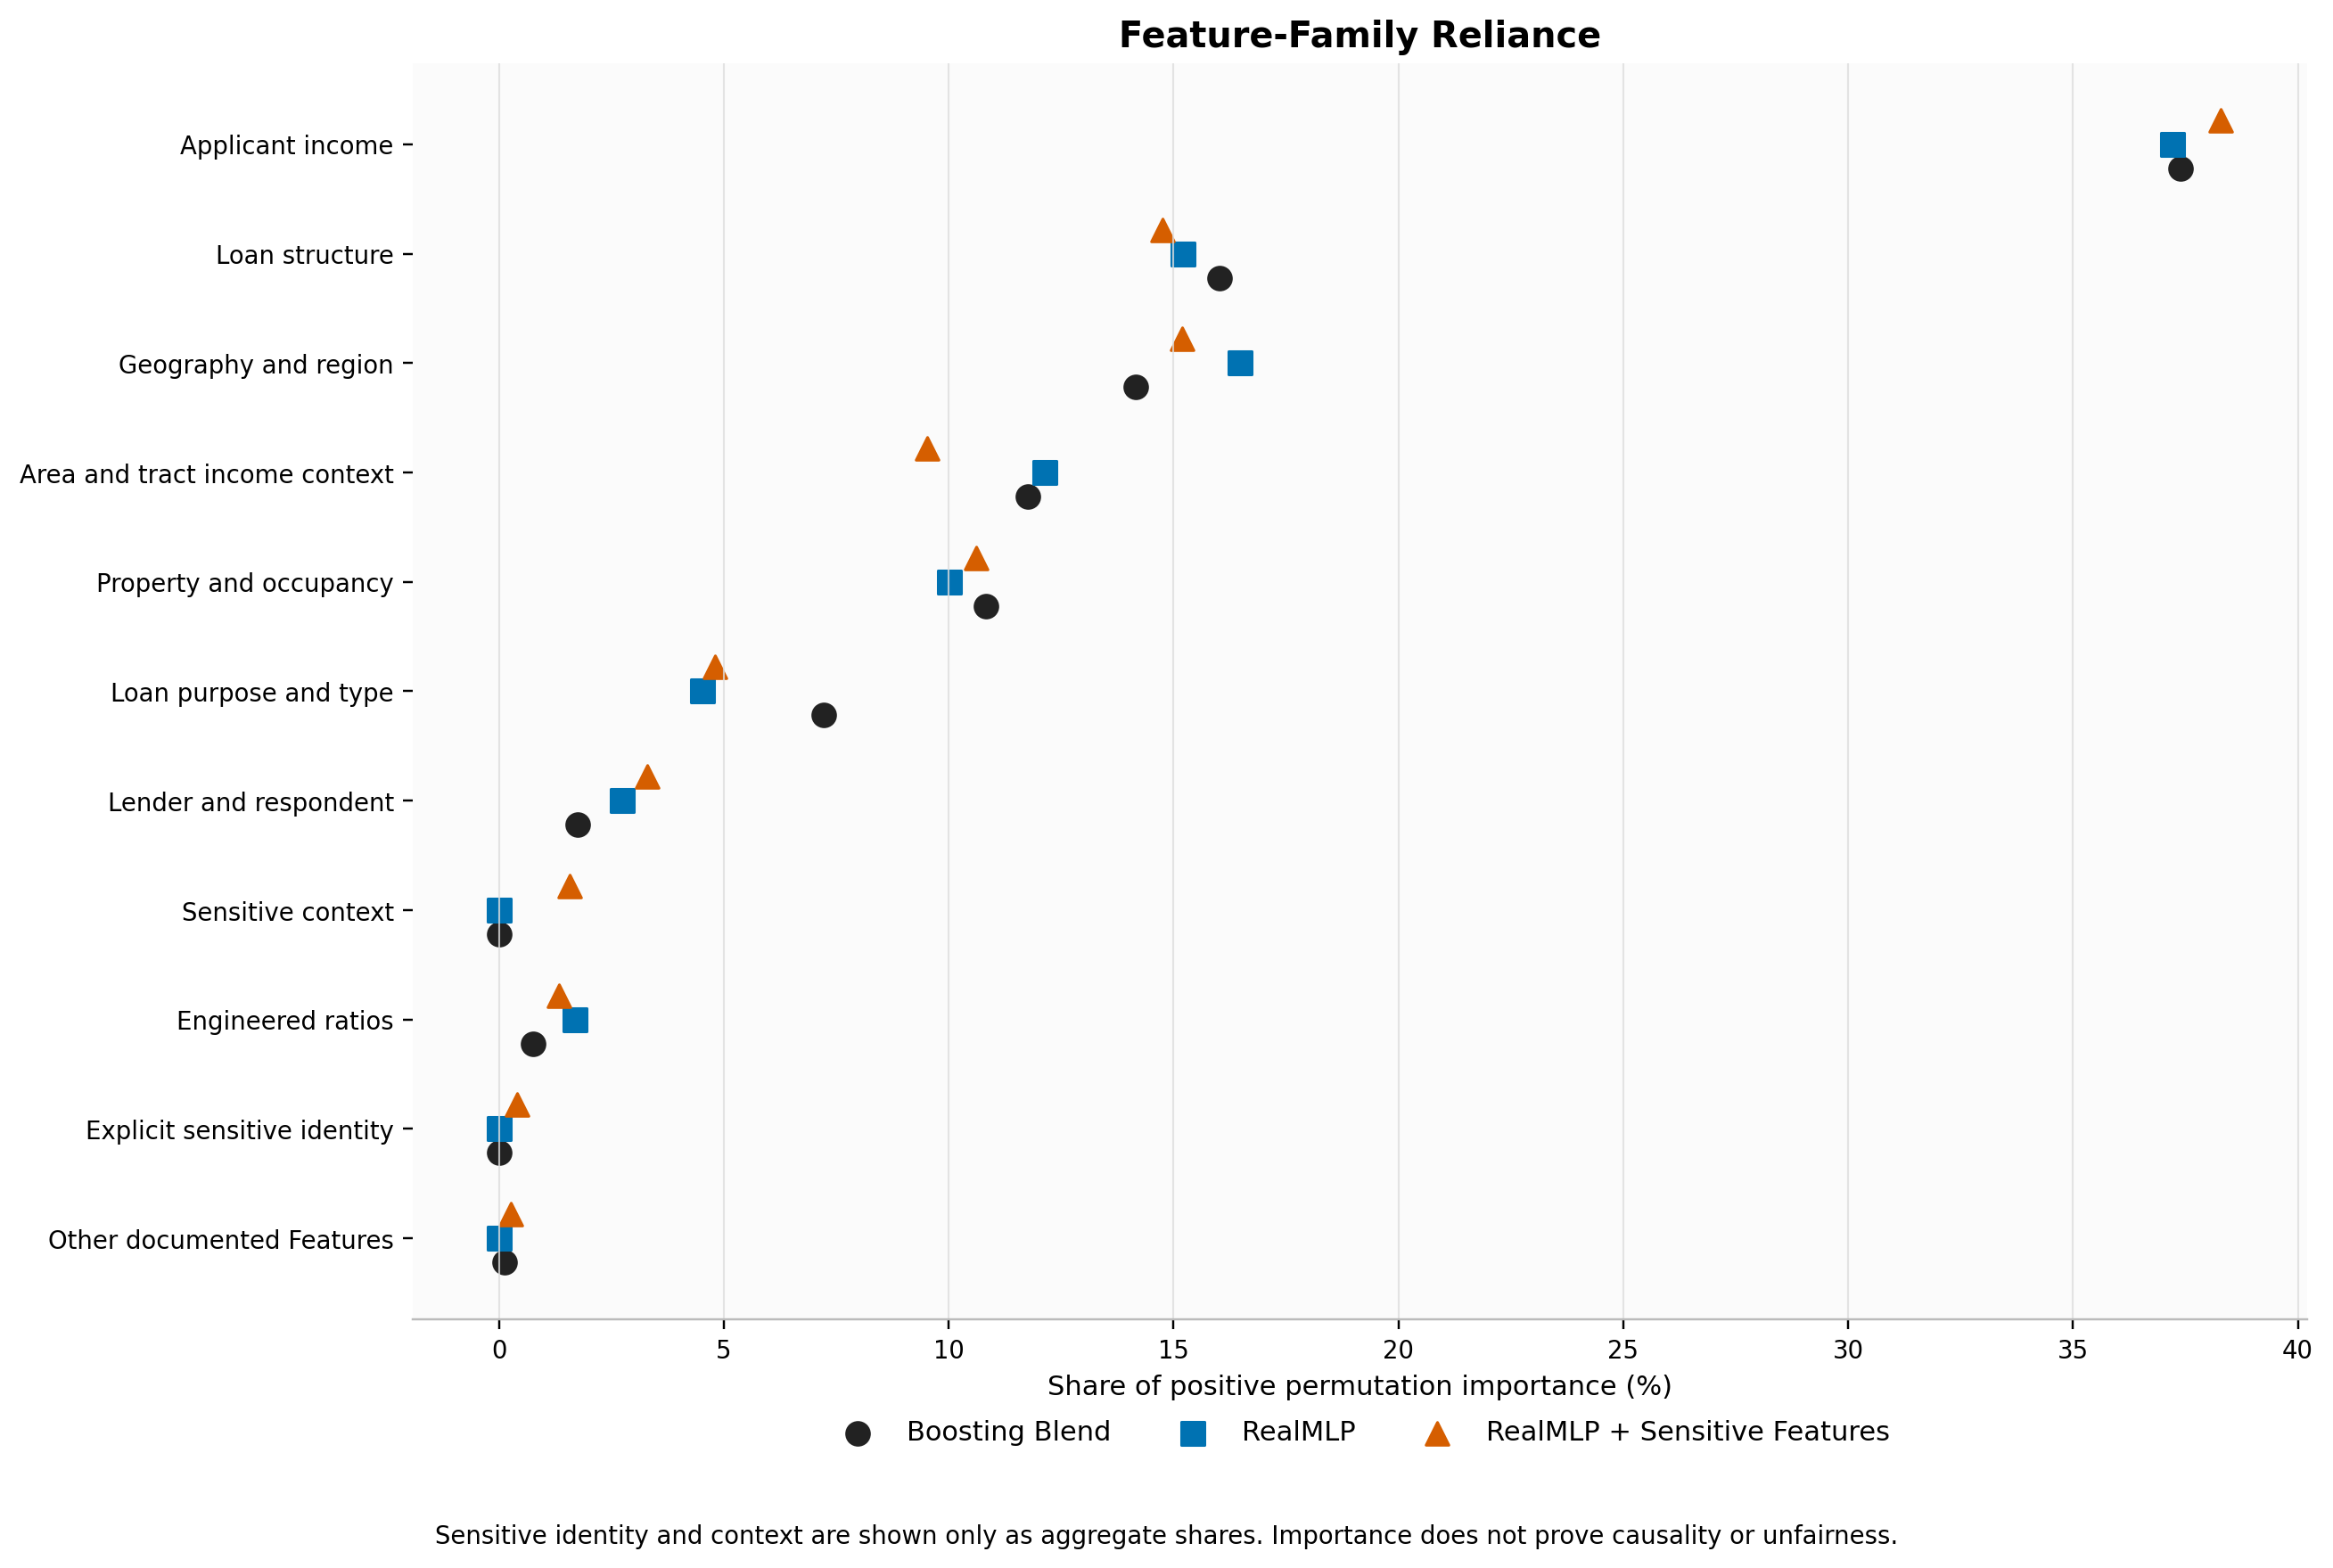

In [25]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_19_feature_family_reliance.png'))

**Main finding:** Income, geography, loan structure, and property context account for most positive permutation importance.

**Why it matters:** Sensitive identity and context shares remain aggregate and do not establish causality or unfairness.

**Table 7 — Top Features**

In [26]:
import pandas as pd
from IPython.display import display
_table = pd.read_csv('artifacts/results/stage9_visual_summary/stage9_visual_summary_feature_table.csv')
display(_table.style.hide(axis='index').format(precision=3))

Feature,Boosting Blend rank,RealMLP rank,RealMLP + Sensitive Features rank,Feature family
Applicant Income,1.000,1.000,1.000,Applicant income
Lien Status Name,2.000,2.000,2.000,Loan structure and lien status
Owner Occupancy Name,3.000,4.000,3.000,Property and occupancy
Msamd Name,8.000,3.000,4.000,Geography and region
Tract Income Ratio,5.000,5.000,5.000,Tract and area income context
Hud Median Family Income,4.000,7.000,7.000,Tract and area income context
Loan Purpose Name,6.000,8.000,8.000,Loan purpose and type
Us Region,10.000,6.000,6.000,Geography and region
Loan Type Name,11.000,10.000,10.000,Loan purpose and type
Respondent Id,13.000,9.000,9.000,"Lender, respondent, and agency"


## 10. Fairness and Sensitive-Feature Comparison

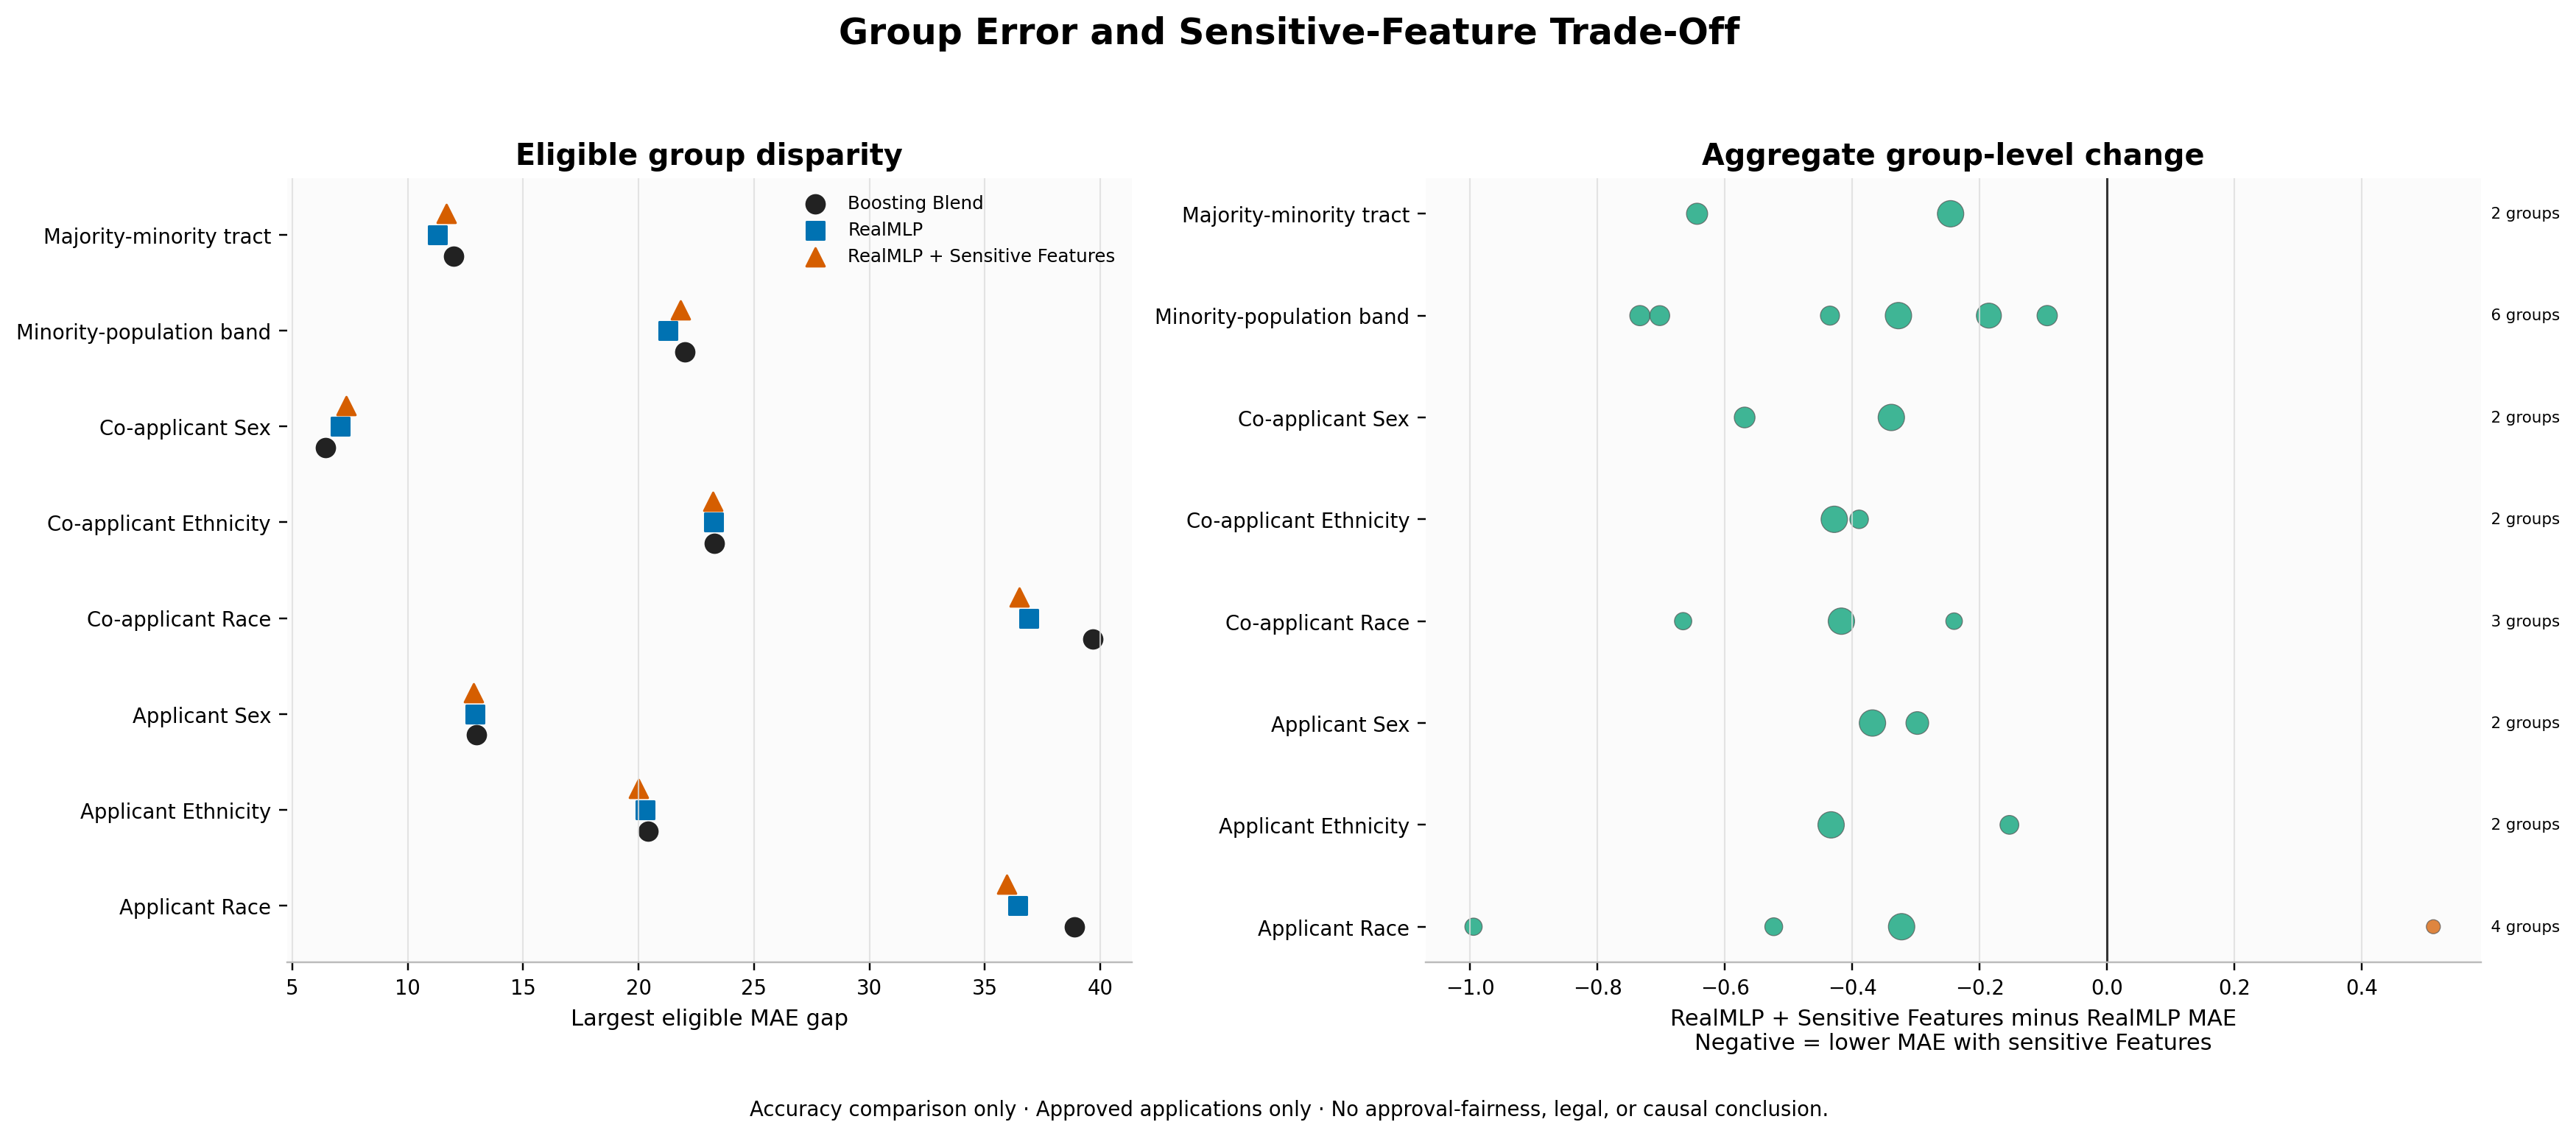

In [27]:
from IPython.display import Image, display
display(Image(filename='artifacts/figures/stage9_visual_summary/figure_20_group_error_sensitive_tradeoff.png'))

**Main finding:** Eligible group gaps vary by attribute, while sensitive Features change group MAE in both directions.

**Why it matters:** This is an accuracy-only comparison for approved applications, not an approval-fairness or legal conclusion.

**Table 8 — Group Performance Summary**

In [28]:
import pandas as pd
from IPython.display import display
_table = pd.read_csv('artifacts/results/stage9_visual_summary/stage9_visual_summary_fairness_table.csv')
display(_table.style.hide(axis='index').format(precision=3))

Sensitive attribute,Eligible group count,Largest MAE gap,Target-standardized gap,Underprediction-rate spread,With-sensitive versus without-sensitive MAE change
Applicant Ethnicity,2,20.401,15.474,0.005,-0.339
Applicant Race,4,38.863,13.427,0.060,-0.339
Applicant Sex,2,12.983,4.308,0.033,-0.339
Co-applicant Ethnicity,2,23.282,17.017,0.016,-0.339
Co-applicant Race,3,39.688,13.444,0.057,-0.339
Co-applicant Sex,2,7.324,2.502,0.000,-0.339
Majority-minority tract,2,11.987,12.433,0.008,-0.339
Minority-population band,6,22.001,19.113,0.036,-0.339


## 11. Model Decisions

**Table 4 — Main Model Decisions**

In [29]:
import pandas as pd
from IPython.display import display
_table = pd.read_csv('artifacts/results/stage9_visual_summary/stage9_visual_summary_decisions.csv')
display(_table.style.hide(axis='index').format(precision=3))

Model or method,Decision,Quantitative reason,Main trade-off
Lasso,Continued,Cross-validated MAE 72.23,Strongest sparse linear benchmark
HistGradientBoosting,Continued,Cross-validated MAE 64.28,Lowest tree-family MAE
CatBoost,Continued,Validation MAE 63.38,Best single boosting component
LightGBM,Continued,Validation MAE 64.46,Useful blend diversity; higher standalone MAE
XGBoost,Continued,Validation MAE 64.22,Useful blend diversity; heavier tail
Boosting Blend,Continued,Validation MAE 63.13,Official test model
RealMLP,Continued,Validation MAE 63.92,Later descriptive comparison only
TabM,Stopped,Screening MAE 66.12,Did not lead deep screening
FT-Transformer,Stopped,Validation MAE 64.46,Higher MAE than RealMLP
RealMLP + Boosting Blend,Stopped,MAE improved 0.44%; RMSE worsened 0.35%,RMSE gate exceeded 0.25% limit


> **Important limitations**
>
> - Approved applications only
> - Official versus later descriptive Test comparison
> - Large-loan tail errors
> - Accuracy comparison is not fairness certification
> - Feature importance is not causality
> - Future-data performance may differ

Supporting documents: [Executive Summary](artifacts/reports/stage9_executive_summary.md) · [Formal Technical Report](REGRESSION_PART9_MODEL_CARD_TECHNICAL_REPORT.ipynb) · [Verification](artifacts/reports/stage9_visual_summary_verification.json)